In [1]:
##importing libraries
import io
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from dipy.segment.mask import median_otsu
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.font_manager as fm
from IPython.display import display, Image
import time

/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# #Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cpu


In [3]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [4]:
##pytorch details
!pip show torch

/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/bin/pip: line 2: /Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_cvae/cvae/bin/python3: No such file or directory
/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/bin/pip: line 2: exec: /Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_cvae/cvae/bin/python3: cannot execute: No such file or directory


In [5]:
torch.__version__

'2.12.1'

In [6]:
# ##Checking torch version, cuda, GPU and memory 
# print(torch.__version__)              # Should show +cu128 (not +cpu)

# print(torch.cuda.is_available())      # Should be True
# # print(torch.cuda.get_device_name(0))  # Should show "NVIDIA GeForce GTX 1650 Ti"
# print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

## **DATASET**

In [7]:
##loding data
if not torch.cuda.is_available():
    path = "/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/notebooks/BRAIN"
else:
    path = "C:\\Users\\Acer\\Desktop\\Saroj_Project\\IVIM_Autoencoder\\notebooks\\BRAIN"

raw_data=nib.load(path+"/data.nii.gz")
mri_data=raw_data.get_fdata()
print(mri_data.shape)

(256, 256, 54, 21)


## **Data description**
1. H: Height of one image in the sequence
2. W: Width of one image in the sequence
3. D: Depth of images or Number of images in the sequence
4. C: Number of channels (like 3 RGB or b-values)

In [8]:
# Load b-values from the file
with open(path+"/bvalues.bval", "r") as f:
    bvals_str = f.read().split()
bvals_arr = np.array([float(b) for b in bvals_str], dtype=np.float32)

print(f"Loaded b-values: {bvals_arr}")
print(f"Number of b-values (N_b): {len(bvals_arr)}")

Loaded b-values: [   0.   10.   20.   30.   40.   60.   80.  100.  120.  140.  160.  180.
  200.  300.  400.  500.  600.  700.  800.  900. 1000.]
Number of b-values (N_b): 21


In [9]:
bvals_arr

array([   0.,   10.,   20.,   30.,   40.,   60.,   80.,  100.,  120.,
        140.,  160.,  180.,  200.,  300.,  400.,  500.,  600.,  700.,
        800.,  900., 1000.], dtype=float32)

## **DATA PREPROCESSING FOR SIMILAR NEIGHBOURING PIXELS EXTRACTION**

In [10]:
# img = raw_train_data[:,:,20,0]
# #for standardize the pixel values
# # mean = np.mean(img)
# # std = np.std(img)
# # img = img-mean
# # img = img/std
# plt.hist(img.flatten(),bins=200)
# plt.show()


In [11]:
#Slice axis 3 (b-value) at index 0, keeping all H, W, and D
b0_raw = mri_data[:, :, :, 0]  #(256, 256, 54) -> (H, W, D)

# Generate the mask using the correct 3D spatial volume
_, otsu_mask = median_otsu(b0_raw, median_radius=3, numpass=2)
brain_msk = otsu_mask.astype(np.uint8)   # (256, 256, 54) -> (H, W, D)

#Correct spatial dimension
print("Mask shape (H, W, D):", brain_msk.shape)  #(256, 256, 54)


Mask shape (H, W, D): (256, 256, 54)


In [12]:
# #Slice Brain Masks to Match
# train_mask = brain_msk[:, :, :train_end]
# val_mask   = brain_msk[:, :, train_end:val_end]
# test_mask  = brain_msk[:, :, val_end:]

# print(f'shape of train: {train_mask.shape}')
# print(f'shape of val: {val_mask.shape}')
# print(f'shape of test: {test_mask.shape}')

In [13]:
def spatial_slab_split(data, mask, val_ratio=0.15, test_ratio=0.15, buffer_slices=1):
    """
    Splits 3D/4D dMRI brain data into Train/Val/Test along Z-axis slabs
    with buffer slice margins to prevent spatial leakage.
    """
    H, W, D = mask.shape
    num_val = int(D * val_ratio)
    num_test = int(D * test_ratio)
    num_train = D - num_val - num_test - (2 * buffer_slices)
    
    train_end = num_train
    val_start = train_end + buffer_slices
    val_end = val_start + num_val
    test_start = val_end + buffer_slices
    
    train_mask = np.zeros_like(mask)
    val_mask   = np.zeros_like(mask)
    test_mask  = np.zeros_like(mask)
    
    train_mask[:, :, :train_end] = mask[:, :, :train_end]
    val_mask[:, :, val_start:val_end] = mask[:, :, val_start:val_end]
    test_mask[:, :, test_start:] = mask[:, :, test_start:]
    
    print(f"Train slices: 0..{train_end-1}")
    print(f"Val slices:   {val_start}..{val_end-1} (Buffer dropped: {train_end}..{val_start-1})")
    print(f"Test slices:  {test_start}..{D-1} (Buffer dropped: {val_end}..{test_start-1})")
    
    return train_mask, val_mask, test_mask

In [14]:
train_mask, val_mask, test_mask = spatial_slab_split(brain_msk, brain_msk, val_ratio=0.15, test_ratio=0.15, buffer_slices=1)

Train slices: 0..35
Val slices:   37..44 (Buffer dropped: 36..36)
Test slices:  46..53 (Buffer dropped: 45..45)


In [15]:
##spliting data into train, val and test
raw_train_data = mri_data * train_mask[:, :, :, np.newaxis]
raw_val_data   = mri_data * val_mask[:, :, :, np.newaxis]
raw_test_data  = mri_data * test_mask[:, :, :, np.newaxis]

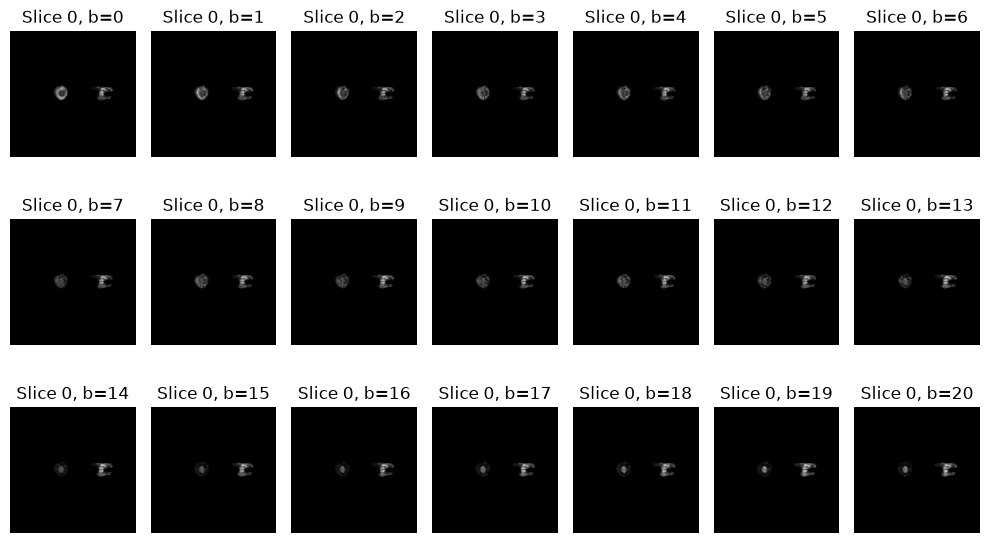

In [16]:
##displaying the 2 slice of mri data over 21 b-value
fig, ax = plt.subplots(3,7, figsize=(10,6))

# Flatten the 2D array of axes into a 1D array for easier iteration
flat_axes = ax.ravel()

plot_counter = 0
# Iterate over the first three slices (depth dimension) of the MRI data
for i in range(raw_train_data[:,:,:3,:].shape[2]):
  # Iterate over all b-values
  for j in range(raw_train_data.shape[3]): # j will be 0 to 20 b-values
    if plot_counter < len(flat_axes): # Check if there are still subplots available
      current_ax = flat_axes[plot_counter]
      current_ax.imshow(raw_train_data[:,:,i,j], cmap='gray')
      current_ax.set_title(f"Slice {i}, b={j}") # Add a title for context
      current_ax.axis('off') # Turn off axis labels for cleaner display
      plot_counter += 1

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

In [17]:
##process in the chunk to speed up
def process_chunk(padded_px, padded_b0, y, x, dy, dx,
                    center_flat_idx, target_slots, b_value):
    """
    Broadcasting Technique:
      Vectorized core, run on one chunk of pixels at a time so peak memory
    stays bounded regardless of total voxel count N.
    """

    n = len(y)

    ##Broadcasting technique to speed up the calculation
    #Build 5x5 neighborhood (25 positions per pixel) fetch using 5x5 window
    yy = y[:, None] + dy[None, :]
    xx = x[:, None] + dx[None, :]

    ##similar neighbouring pixels calculation
    b0_neighbors = padded_b0[yy, xx]              # (n, 25)
    center_b0 = padded_b0[y, x]                     # (n,)
    similarity = np.abs(center_b0[:, None] - b0_neighbors)  # (n, 25)

    ##a masking array of 25 boolean coordinate
    ##removing center coordinate from the extracted 5x5 similarity matrix
    keep = np.ones(25, dtype=bool)
    keep[center_flat_idx] = False

    ##indexing drops/remove center from the column where keep==false
    # Drops the center coordinates
    similarity = similarity[:, keep] # (n, 24)
    yy, xx = yy[:, keep], xx[:, keep]

    #sort the python list.sort() 
    #order indices says which column to pick per row  
    order = np.argsort(similarity, axis=1, kind='stable')  # (n, 24)
    top8_indices = order[:, :8]

    ##select values from an array along a specified axis using index arrays
    yy_top = np.take_along_axis(yy, top8_indices, axis=1)      # (n, 8)
    xx_top = np.take_along_axis(xx, top8_indices, axis=1)
    full_top8 = padded_px[:, yy_top, xx_top]  # (b_value, n, 8)

    ##initialize the 3x3 patch of most similar pixels
    block = np.zeros((n, 3, 3, b_value), dtype=np.float32)
    center_vals = padded_px[:, y, x]             # (b_value, n)
    block[:, 1, 1, :] = center_vals.T

    vals = np.transpose(full_top8, (1, 2, 0))           # (n, 8, b_value)
    block[:, target_slots[:, 0], target_slots[:, 1], :] = vals

    return block


##extracting the similar neighbouring pixels patches 
def similar_neighborhood_patch(data, brain_masker, chunk_size=2000):
    H, W, D, b_value = data.shape

    y_factor = 2.0 / (H - 1) if H > 1 else 1.0
    x_factor = 2.0 / (W - 1) if W > 1 else 1.0

    similar_patch, center_coord, norm_cent_coord  = [], [], []

    #Looping over each slices
    for i in range(D):
      slices_data = data[:, :, i, :]

      mri_slice = np.transpose(slices_data, (2, 0, 1))  # (b, H, W)
      
      #brain mask slicing (no transpose needed for 2D)
      brain_mask_slice = brain_masker[:, :, i]  # (H, W)

      ##Intensity normalization
      b0_original = mri_slice[0].copy()
      ##select only valid pixels
      b0_valid_px = np.where(b0_original==0, 1e-8, b0_original)
      ##normalize
      mri_slice_norm = mri_slice/b0_valid_px[None:, :]

      #Threshold
      #Finds the actual intensity mean of the b=0 brain pixels, not mask density
      b0_image = mri_slice[0]
      b0_img_mean = np.mean(b0_image[brain_mask_slice > 0]) if np.any(brain_mask_slice > 0) else 0
      b0_threshold = 0.50 * b0_img_mean

      # Find indices based on corrected 2D mask and threshold
      brain_indices = np.argwhere((brain_mask_slice > 0) & (b0_image >= b0_threshold))
      N = len(brain_indices)
      print(f"Slice {i}/{D-1}: Processing {N} brain pixels to build 2D similarity blocks")

      ##if number of voxels is zero continue calculation
      if N == 0:
          continue
      
      ##padding tensors
      ##padded signal at b-value=0
      padded_px = np.pad(mri_slice_norm, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
      padded_b0 = np.pad(b0_original, ((2, 2), (2, 2)), mode='constant', constant_values=0)


      ##x and y coordinates of brain indices with padding
      y_all = (brain_indices[:, 0] + 2).astype(np.int32)
      x_all = (brain_indices[:, 1] + 2).astype(np.int32)

      ##array ranging from -2 to 3, for generating a 5x5 window: array([-2, -1,  0,  1,  2])
      ##5x5 window matrix
      ##flatten them in 1d array
      ##offset coordinate index for central pixel
      offs = np.arange(-2, 3, dtype=np.int32)
      dy, dx = np.meshgrid(offs, offs, indexing='ij')
      dy, dx = dy.ravel(), dx.ravel()
      center_flat_idx = 12  #(0,0) offset's position in the flatten 25-length grid

      ##initialize the empty neighbors slot to store top neighbor pixels later in calculation
      top_neighbors_slot = np.array([
          (a, b) for a in range(3) for b in range(3) if not (a == 1 and b == 1)
          ])

      ##initialize the empty similar neighbourhood block array
      similar_neig_block = np.zeros((N, 3, 3, b_value), dtype=np.float32)

      ##actual similar neighbourhood data calculated in chunks and store in pre-defined similar_neig_block
      for start in range(0, N, chunk_size):
          end = min(start + chunk_size, N)
          similar_neig_block[start:end] = process_chunk(padded_px, padded_b0, y_all[start:end], x_all[start:end],
                                                    dy, dx, center_flat_idx, top_neighbors_slot, b_value)

      center_coords = list(map(tuple, brain_indices))
      y0 = brain_indices[:, 0] * y_factor - 1.0
      x0 = brain_indices[:, 1] * x_factor - 1.0
      center_norm_coord = list(zip(y0.tolist(), x0.tolist()))

      similar_patch.append(similar_neig_block)
      center_coord.append(center_coords)
      norm_cent_coord.append(center_norm_coord)
      
    print("Processing completed.")
    return similar_patch, center_coord, norm_cent_coord


In [18]:
#Run Patches extraction function independently on each chunk
print("Extracting Training Patches")
train_patches, _, train_norm_coords = similar_neighborhood_patch(raw_train_data, train_mask)

print("\nExtracting Validation Patches")
val_patches, _, val_norm_coords = similar_neighborhood_patch(raw_val_data, val_mask)

print("\nExtracting Testing Patches")
test_patches, test_coords, test_norm_coords = similar_neighborhood_patch(raw_test_data, test_mask)

#Concatenate slices into monolithic numpy arrays
X_train = np.concatenate(train_patches, axis=0)  # (N_train, 3, 3, b_value)
X_val   = np.concatenate(val_patches, axis=0)    # (N_val, 3, 3, b_value)
X_test  = np.concatenate(test_patches, axis=0)   # (N_test, 3, 3, b_value)

# Flatten the coordinate lists for conditional context
coord_train = np.array([c for slice_c in train_norm_coords for c in slice_c], dtype=np.float32)
coord_val   = np.array([c for slice_c in val_norm_coords for c in slice_c], dtype=np.float32)
coord_test  = np.array([c for slice_c in test_norm_coords for c in slice_c], dtype=np.float32)


Extracting Training Patches
Slice 0/53: Processing 1100 brain pixels to build 2D similarity blocks
Slice 1/53: Processing 1311 brain pixels to build 2D similarity blocks
Slice 2/53: Processing 1669 brain pixels to build 2D similarity blocks
Slice 3/53: Processing 2411 brain pixels to build 2D similarity blocks
Slice 4/53: Processing 3326 brain pixels to build 2D similarity blocks
Slice 5/53: Processing 4100 brain pixels to build 2D similarity blocks
Slice 6/53: Processing 4728 brain pixels to build 2D similarity blocks
Slice 7/53: Processing 5202 brain pixels to build 2D similarity blocks
Slice 8/53: Processing 5564 brain pixels to build 2D similarity blocks
Slice 9/53: Processing 5959 brain pixels to build 2D similarity blocks
Slice 10/53: Processing 6853 brain pixels to build 2D similarity blocks
Slice 11/53: Processing 8110 brain pixels to build 2D similarity blocks
Slice 12/53: Processing 9335 brain pixels to build 2D similarity blocks
Slice 13/53: Processing 10477 brain pixels to 

In [19]:
X_train[0]

array([[[1.        , 0.7744465 , 0.8072117 , 0.82781136, 0.7441167 ,
         0.69936264, 0.74761045, 0.5867344 , 0.60328937, 0.53246814,
         0.5386402 , 0.4151038 , 0.44574443, 0.31591532, 0.22135457,
         0.20950624, 0.18000263, 0.1953747 , 0.13910598, 0.15617156,
         0.09742675],
        [1.        , 0.5533619 , 0.32959533, 0.74360824, 0.4694777 ,
         0.47384518, 0.1972078 , 0.14794442, 0.35720235, 0.34725583,
         0.30239362, 0.28878242, 0.22946423, 0.1247082 , 0.14151078,
         0.1005993 , 0.11296628, 0.09627642, 0.12547806, 0.11951357,
         0.10411981],
        [1.        , 0.6769471 , 0.4590843 , 0.92023176, 0.5630377 ,
         0.7006244 , 0.526972  , 0.37602347, 0.6541385 , 0.5708311 ,
         0.4515527 , 0.44367996, 0.28467622, 0.2368071 , 0.1921778 ,
         0.16893184, 0.1782051 , 0.12974456, 0.13714117, 0.1039773 ,
         0.12513176]],

       [[1.        , 0.65984577, 0.670416  , 0.6672307 , 0.64407486,
         0.62850356, 0.5571481 , 0.

In [20]:
# ##display 3x3 block
# plt.imshow(X_train[0][0,:,:,0], cmap='gray') # Display the signal at 21 b-value of the first block's middle depth slice
# plt.show()

# X_train[0] ##shape=(119110, 3, 3, 21)

# x=torch.from_numpy(X_train[0]).float()
# x.shape


# ##shape=(119110, 3, 3, 21) -----> shape=(119110, 21, 3, 3) ----> Idx shape=(0, 3, 1, 2)
# x1=x.permute(2, 0, 1) 
# x1.shape


# print(x1[:,0:1, :, : ])
# x1[:, 0:1, :, : ].shape ##torch.Size([21, 3, 3])


# x1[:,0:1,:,:][0].shape

# ##b0_image
# plt.imshow(x1[:, 0:1, :, :][0], cmap='gray')
# plt.show()


# # Visualise the highest b-value (e.g., index -1), with non-zero b-value
# plt.imshow(x1[0, -1, :, :], cmap="gray", vmin=0, vmax=1)
# plt.colorbar()
# plt.show()

In [21]:
##A custom data creator function
class DiffusionDataset(Dataset):
    def __init__(self, similar_patches, condition):
        """
        similar_patches: NumPy array of shape (N, 3, 3, b_values)
        condition (list of coordinates): NumPy array of shape (N, 2) 
        """
        # data is a list of slices, concatenate it into a monolithic array 
        # inside (__init__) to protect from list indexing bugs
        ##checking whether it is a list or array
        if isinstance(similar_patches, list):
            self.patches = np.concatenate(similar_patches, axis=0)
        else:
            self.patches = similar_patches

        # Convert the entire condition dataset to a PyTorch tensor at initialization. 
        # This avoids slow memory re-allocations in __getitem__
        self.condition = torch.tensor(np.array(condition), dtype=torch.float32)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        #convert the individual patch array to a tensor
        x = torch.from_numpy(self.patches[idx]).float()

        # checking dimension for reshaping
        if x.dim() == 3:
            x = x.permute(2, 0, 1)      #(3, 3, b_values) -> (b_values, 3, 3)
        elif x.dim() == 4:
            x = x.permute(0, 3, 1, 2)   #(N, 3, 3, b_values) -> (N, b_values, 3, 3)
        else:
            raise ValueError(f"Unexpected tensor shape {tuple(x.shape)}")

        # Clean, fast index fetch for the condition vector
        y = self.condition[idx]
        return x, y



In [22]:
#INSTANTIATE THE TORCH DATALOADERS
# Voxel-wise/Patch regression networks process data fast. A large batch size 
# improves training speed and stabilizes the CVAE latent space optimization.
BATCH_SIZE = 128  

train_dataset = DiffusionDataset(X_train, coord_train)
val_dataset   = DiffusionDataset(X_val, coord_val)
test_dataset  = DiffusionDataset(X_test, coord_test)

# Training, Validation and Testing data loaders
#Shuffle=True is strictly applied only to training data
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


print(f"Data Loaders successfully created:")
print(f"Train Batches:      {len(train_loader)} (Total patches: {len(train_dataset)})")
print(f"Validation Batches: {len(val_loader)} (Total patches: {len(val_dataset)})")
print(f"Testing Batches:    {len(test_loader)} (Total patches: {len(test_dataset)})")



Data Loaders successfully created:
Train Batches:      3639 (Total patches: 465798)
Validation Batches: 1073 (Total patches: 137341)
Testing Batches:    553 (Total patches: 70681)


In [23]:
# Fetch one test batch and check
for train_x, train_coord in train_loader:
    print(f"Batch X Shape (Expects [4, b_values, 3, 3]): {train_x.shape}")
    print(f"Batch Y Shape (Expects [4, 2]):           {train_coord.shape}")
    print(f"X_train values: {train_x[0,:,:,:]}")
    break


Batch X Shape (Expects [4, b_values, 3, 3]): torch.Size([128, 21, 3, 3])
Batch Y Shape (Expects [4, 2]):           torch.Size([128, 2])
X_train values: tensor([[[1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000]],

        [[0.9623, 0.9189, 0.9731],
         [0.9538, 0.9489, 0.9269],
         [0.9776, 0.9523, 0.9310]],

        [[0.9368, 0.9313, 0.9283],
         [0.9462, 0.9218, 0.9118],
         [0.9207, 0.9026, 0.9039]],

        [[0.9351, 0.8822, 0.9245],
         [0.9393, 0.9248, 0.8936],
         [0.9259, 0.9096, 0.8997]],

        [[0.9278, 0.8983, 0.9328],
         [0.9165, 0.9262, 0.9013],
         [0.9368, 0.9175, 0.8950]],

        [[0.9122, 0.8955, 0.8956],
         [0.9161, 0.9041, 0.8883],
         [0.8937, 0.8760, 0.8818]],

        [[0.8447, 0.8388, 0.8497],
         [0.8564, 0.8408, 0.8256],
         [0.8464, 0.8178, 0.8077]],

        [[0.8047, 0.7856, 0.8542],
         [0.8218, 0.8314, 0.7867],
         [0.8119, 0.7901, 0.7

## **PHYSIOLOGICAL BI-EXPONENTIAL SIGNAL EQUATION**

In [24]:
##Physics IVIM signal function
def ivim_biex_signal(theta, b_vals):
    ##IVIM parameters
    D = theta[:, 0:1]
    Ds = theta[:, 1:2]
    f = theta[:, 2:3]

    #b values broadcastable if b-value is 1D array
    if b_vals.dim()<=2:
        b = b_vals.view(1,-1, 1, 1)
    else:
        b = b_vals.reshape(1, -1, 1, 1)
    
    ##perfusion signal due to the flow of blood
    s_perf = f*torch.exp(-b * Ds)
    ##True diffusion signal due to water molecules in tissues
    s_diff = (1-f)*torch.exp(-b*D)
    ##bi-exponential signal
    s_sum = s_perf + s_diff
    return s_sum, s_perf, s_diff

## **MODEL ARCHITECTURE**

## **UNCERTAINTY QUANTIFICATION WHILE ESTIMATING PARAMETERS**

In [25]:
##MonteCarlo Dropout
class MCDropout(nn.Module):
    """"
    1D dropout layer which enforces the dropout layer to stay active even in
    model evaluation called inference.
    """
    def __init__(self, p:float):
        super().__init__()
        self.p = p
        self.mc_active = True ##by default is always on

    def forward(self, input: torch.Tensor):
        use_dropout = self.mc_active or self.training
        return F.dropout(input, p=self.p, training=use_dropout)

In [26]:
def ivim_signal_variance(D, Ds,f,D_var,Ds_var,
                        f_var,bvalues,eps=1e-10,
                        base_var=1e-6,max_var=1.0):
    """
    Propagate D/Ds/f variance into IVIM signal variance.

    Parameter:
        D: predicted true diffusion, shape (B, 1, 3, 3)
        Ds: predicted pseudo-diffusion, shape (B, 1, 3, 3)
        f: predicted perfusion fraction, shape (B, 1, 3, 3)
        D_var: predicted variance of D, shape (B, 1, 3, 3)
        Ds_var: predicted variance of Ds, shape (B, 1, 3, 3)
        f_var: predicted variance of f, shape (B, 1, 3, 3)
        bvalues: b-values tensor
        eps: numerical floor
        base_var: small baseline signal variance to avoid collapse
        max_var: upper bound for signal variance

    Returns:
        signal_var: shape (B, num_bvalues, 3, 3)
    """

    b = bvalues.view(1, -1, 1, 1)

    exp_D = torch.exp(-b * D)
    exp_Ds = torch.exp(-b * Ds)

    dS_dD = -(1.0 - f) * b * exp_D
    dS_dDs = -f * b * exp_Ds
    dS_df = exp_Ds - exp_D

    signal_var = ( dS_dD.pow(2) * D_var + dS_dDs.pow(2) * Ds_var + dS_df.pow(2) * f_var + base_var)

    signal_var = torch.clamp(signal_var, min=eps, max=max_var)

    return signal_var

In [27]:
def heteroscedastic_signal_loss(recon,target,signal_var,bvalues=None,
                                eps=1e-10,mask_b0=True):
    """
    Gaussian heteroscedastic negative log-likelihood on reconstructed IVIM signal.

    Parameter:
        recon: predicted signal, shape (B, num_bvalues, 3, 3)
        target: observed signal, shape (B, num_bvalues, 3, 3)
        signal_var: predicted signal variance, shape (B, num_bvalues, 3, 3)
        bvalues: b-values tensor. If provided and mask_b0=True, b=0 is ignored.
        eps: numerical floor
        mask_b0: whether to exclude b=0 from the loss

    Returns:
        scalar loss
    """

    nll = 0.5 * (torch.log(signal_var + eps) + ((target - recon) ** 2) / (signal_var + eps))

    if mask_b0 and bvalues is not None:
        mask = (bvalues.view(1, -1, 1, 1) > 0).float().to(nll.device)
        mask = mask.expand_as(nll)

        masked_nll = nll * mask
        denom = mask.sum().clamp(min=1.0)

        return masked_nll.sum() / denom

    return nll.mean()

In [28]:
def ivim_physics_penalty(D, Ds, f, f_max=0.300):
    """
    Physics/physiological regularization for D, Ds, f.
    """

    f_prior = 0.20

    f_too_low = (f < 0.02).float()
    f_too_high = (f > f_max - 0.02).float()

    f_reg = (torch.mean((f - f_prior).pow(2) * f_too_low) * 10.0 + torch.mean((f - f_prior).pow(2) * f_too_high) * 10.0)

    #Enforces D* > D (pseudo-diffusion > true diffusion)
    diff_reg = torch.mean(F.relu(D - Ds + 1e-6) ** 2)

    #Spatial smoothness on 3x3 patch
    smooth_d_v = torch.mean((D[:, :, 1:, :] - D[:, :, :-1, :]) ** 2)
    smooth_ds_v = torch.mean((Ds[:, :, 1:, :] - Ds[:, :, :-1, :]) ** 2)
    smooth_d_h = torch.mean((D[:, :, :, 1:] - D[:, :, :, :-1]) ** 2)
    smooth_ds_h = torch.mean((Ds[:, :, :, 1:] - Ds[:, :, :, :-1]) ** 2)

    smoothness = smooth_d_v + smooth_ds_v + smooth_d_h + smooth_ds_h
    physics_penalty = (f_reg * 1.0 + diff_reg * 10.0 + smoothness * 0.1)
    return physics_penalty

In [29]:
##Physics informed IVIM cVAE
class PhysicsCVAE(nn.Module):
    """
    Physics-Informed Conditional Variational Autoencoder (PIcVAE) for IVIM parameter estimation.

    Architecture
    Encoder: 2D CNN on 3x3 multi-b-value patches(coordinate-free)
    Decoder: z + normalised spatial coords ---> IVIM bi-exponential forward model
    """

    D_min: torch.Tensor
    D_max: torch.Tensor
    D_range: torch.Tensor

    Ds_min: torch.Tensor
    Ds_max: torch.Tensor
    Ds_range: torch.Tensor

    f_min: torch.Tensor
    f_max: torch.Tensor
    f_range: torch.Tensor

    logvar_min: torch.Tensor
    D_logvar_max: torch.Tensor
    Ds_logvar_max: torch.Tensor
    f_logvar_max: torch.Tensor

    def __init__(self, 
                 in_channel:int, 
                 bvalues: torch.Tensor, 
                 latent_dim:int, 
                 coord_dim=2, 
                 bvals=None, 
                 dropout_p=0.10):
        """
        Parameters:
        in_channel  (int):   Number of b-values (input channels).
        bvalues     (Tensor): 1-D tensor of b-values (s/mm²).
        latent_dim  (int):   Dimensionality of latent vector z.
        coord_dim   (int):   Spatial coordinate dimensions (default 2 for x, y).
        dropout_p   (float): MC-Dropout probability in decoder.
        """
        super().__init__()
        self.latent_dim = latent_dim
        self.coord_dim = coord_dim

        ##Physiological Constant ranges
        D_min, D_max = 0.0005, 0.002 #Water restriction boundaries
        Ds_min, Ds_max = 0.005, 0.10 #High-velocity capillary perfusion micro-circulation
        f_min, f_max = 0.025, 0.40 #Capillary plasma fraction cap(50%)
        ##registering b-values as buffer parameters
        self.register_buffer("bvalues", bvalues.view(1, -1, 1, 1)) 

        ##ENCODER NET
        # Input:  (B, in_channel, 3, 3)
        # Output: (B, 576)   [64 channels x 3 x 3, flattened]

        self.encoder_net = nn.Sequential(
            ##first conv layer
            nn.Conv2d(in_channel, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            MCDropout(0.40),

            nn.Conv2d(128,256,kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            MCDropout(0.30),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            MCDropout(0.20),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Flatten()
        )

        ## 64 CNN output channel, 3-Height, 3-Width 
        ##encoder output
        encoder_output_dim = 64*3*3 



        ##mean and variance for latent space
        self.fc_mu = nn.Linear(encoder_output_dim, latent_dim)
        self.fc_logvar = nn.Linear(encoder_output_dim, latent_dim)

        ##DECODER NET: conditioned on normalized spatial coordinates
        ##conditional vector layer
        self.de_coord_layer = nn.Sequential(
            nn.Linear(self.coord_dim, 8),
            nn.GELU()
        )

        ##combined 
        combined_decoder_size = self.latent_dim+8

        self.decoder_net = nn.Sequential(
            nn.Linear(combined_decoder_size, 64), 
            nn.GELU(),
            MCDropout(0.30)
        )

        ##Decoder output for D,D*,f (mean and variance)
        self.param_mu_head = nn.Linear(64, 3*3*3)
        self.param_logvar_head = nn.Linear(64, 3*3*3)

        # Initialize parameter logvar bias to a reasonable starting scale
        nn.init.constant_(self.param_logvar_head.weight, 0.0)
        nn.init.constant_(self.param_logvar_head.bias, -6.0)

        # Ranges
        self.register_buffer("D_min",   torch.tensor(D_min,  dtype=torch.float32))
        self.register_buffer("D_max",   torch.tensor(D_max,  dtype=torch.float32))
        self.register_buffer("D_range", torch.tensor(D_max - D_min, dtype=torch.float32))

        self.register_buffer("Ds_min",   torch.tensor(Ds_min,  dtype=torch.float32))
        self.register_buffer("Ds_max",   torch.tensor(Ds_max,  dtype=torch.float32))
        self.register_buffer("Ds_range", torch.tensor(Ds_max - Ds_min, dtype=torch.float32))

        self.register_buffer("f_min",   torch.tensor(f_min,  dtype=torch.float32))
        self.register_buffer("f_max",   torch.tensor(f_max,  dtype=torch.float32))
        self.register_buffer("f_range", torch.tensor(f_max - f_min, dtype=torch.float32))

        # Allow parameter variances to scale up to the full range squared, 
        # but give logvar room up to 0.0 (variance of 1.0 in normalized parameter space)
        self.register_buffer("logvar_min",    torch.tensor(-15.0, dtype=torch.float32))
        self.register_buffer("D_logvar_max",  torch.tensor(-4.0,  dtype=torch.float32))
        self.register_buffer("Ds_logvar_max", torch.tensor(-2.0,  dtype=torch.float32))
        self.register_buffer("f_logvar_max",  torch.tensor(0.0,   dtype=torch.float32))

    ##Split the 27 raw outputs into 3 group (D,Ds,f)
    def split_raw(self, raw_output):
        """ 
        Split Raw output: (B, 27)
        Returns:
            D:  (B, 1, 3, 3)
            Ds: (B, 1, 3, 3)
            f:  (B, 1, 3, 3)
        """
        d_chunk, ds_chunk, f_chunk = torch.chunk(raw_output, chunks=3, dim=1)

        #Reshape to 2D spatial patches: Each becomes (B, 1, 3, 3)
        d_raw = d_chunk.view(-1, 1, 3, 3)
        ds_raw = ds_chunk.view(-1, 1, 3, 3)
        f_raw = f_chunk.view(-1, 1, 3, 3)
        return d_raw, ds_raw, f_raw
    
    # Physical parameter constraints
    def constrain_mean(self, raw_params):
        """
        Split (B, 27) into 3 param maps with physical constraints
        Returns: theta (B, 3, 3, 3) stacked as [D, D*, f]
                Individual: D (B,1,3,3), Ds (B,1,3,3), f (B,1,3,3)
        """

        ##splitting 27 raw outputs into 3 groups of 9 having shape (B, 1, 3, 3)
        d_raw, ds_raw, f_raw = self.split_raw(raw_output=raw_params)

        ##IVIM THREE PARAMETERS
        ##True diffusion
        zero_tensor = torch.zeros_like(d_raw)
        t_d = F.softplus(d_raw)-F.softplus(zero_tensor)
        t_D = torch.clamp(t_d, min=0.0, max=1.0)

        ##Perfusion - pseudo-diffusion
        p_ds = F.softplus(ds_raw)-F.softplus(zero_tensor)
        p_Ds = torch.clamp(p_ds, min=0.0, max=1.0)

        ##perfusion fraction: Perfusion fraction remains a standard native sigmoid percentage 
        p_f = torch.sigmoid(f_raw)

        ##Scaling the three parameters using biophysiological constants 
        D  = self.D_min + t_D*self.D_range
        Ds = self.Ds_min + p_Ds*self.Ds_range
        f  = self.f_min + p_f*self.f_range

        ##Stacking parameters safely back into the (B, 3, 3, 3) shape
        theta_params = torch.cat([D, Ds, f], dim=1)

        return D, Ds, f, theta_params

    ## CVAE methods
    ##ENCODER
    def Encode(self, x_similar_patch:torch.Tensor):
        """Encoder: multi-b-value patch -> (mu, logvar). No coord conditioning"""
        image_vector = self.encoder_net(x_similar_patch) #image feature maps with shape (B, 576) 
        mu = self.fc_mu(image_vector)  
        logvar = self.fc_logvar(image_vector)
        return mu, logvar

    ##LATENT SPACE
    ##Appying reparameterization trick 
    #way to sample the latent variable(z) from the distribution of N(mu, variance)
    def reparameterize(self, mu, logvar):
        """Standard VAE reparameterisation trick: z = mu + sigma * epsilon"""
        ##standard deviation from log-variance
        std = torch.exp(0.5 * logvar) 
        ##epsilon is a noise variable with randomness on it
        eps = torch.randn_like(std) 
        ##reparameterized sample
        z = mu + eps*std
        return z

    #Constrain log-variances and convert to variances
    def compute_params_variance(self, raw):
        """
        raw: (B, 27), interpreted as raw log-variance

        Returns:
            variances: (D_var, Ds_var, f_var)
            logvars:   (D_logvar, Ds_logvar, f_logvar)
        """
        d_raw, ds_raw, f_raw = self.split_raw(raw)

        D_logvar = torch.clamp(d_raw,
                               min=self.logvar_min,
                               max=self.D_logvar_max)
        
        Ds_logvar = torch.clamp(ds_raw,
                                min=self.logvar_min,
                                max=self.Ds_logvar_max)
        f_logvar = torch.clamp(f_raw,
                               min=self.logvar_min,
                               max=self.f_logvar_max)
        
        D_var = torch.exp(D_logvar)
        Ds_var = torch.exp(Ds_logvar)
        f_var = torch.exp(f_logvar)

        variances = (D_var, Ds_var, f_var)
        logvars = (D_logvar, Ds_logvar, f_logvar)

        return variances, logvars
    
    ##DECODER
    def Decode(self, z_sample:torch.Tensor, coord:torch.Tensor):
        """
        Decoder: latent(z) + spatial coords - IVIM bi-exponential signal

        Parameters:
        ----------
        z     : (B, latent_dim)   sampled latent vector
        coord : (B, 2)            normalised spatial coordinates

        Returns
        -------
        s_total    : (B, C_bvals, 3, 3)  reconstructed signal
        components : tuple(s_total, s_perf, s_diff)
        IVIM parameters : tuple(theta, D, Ds, f)
        """
        ##transform the coordinates into vector form in shape (B, coord)
        coord_vec = self.de_coord_layer(coord) ##(B, 8)
        ##coordinate vectors and z-samples combine together again
        de_input = torch.cat([z_sample, coord_vec], dim=1) ##(B, latent_dim+2)
        ##decoder layer generates the raw parameters
        raw_pars = self.decoder_net(de_input) ##(B, 27)

        mean_raw = self.param_mu_head(raw_pars)
        logvar_raw = self.param_logvar_head(raw_pars)

        ##apply physical constraint
        D, Ds, f, theta = self.constrain_mean(mean_raw)

        variances, logvars = self.compute_params_variance(logvar_raw)

        ##feeding into the external IVIM bi-exponential function
        s_total, s_perf, s_diff = ivim_biex_signal(theta, self.bvalues)

        components = (s_total, s_perf, s_diff)
        params = (theta, D, Ds, f)

        return s_total, components, params, variances, logvars

    ##FORWARD PASS
    def forward(self, x_inputs:torch.Tensor, c_condition:torch.Tensor):
        """ Full forward pass: encode -> reparameterise -> decode """
        ##Encoder
        mu, log_var = self.Encode(x_similar_patch=x_inputs)
        ##Reparameterization
        z = self.reparameterize(mu, log_var)
        ##Decoder
        recon, components, parameters, variances, logvars = self.Decode(z, coord=c_condition)
        return recon, mu, log_var, components, parameters, variances, logvars

    # MC Dropout control — toggle for training vs validation vs UQ
    def mc_dropout_set(self, active: bool):
        """Enable/disable MC mode for all MCDropout layers.

        Parameters
        active : bool
            True: dropout always ON  (for MC uncertainty estimation)
            False: dropout follows normal train/eval (for deterministic val)
        """
        for module in self.modules():
            if isinstance(module, MCDropout):
                module.mc_active = active

    #RECONSTRUCTION LOSS WITH KL-DIVERGENCE
    ##SUM is change into mean for reconstruction
    def cvae_loss(self, recons: torch.Tensor,
                    x: torch.Tensor,
                    mu: torch.Tensor,
                    logvar: torch.Tensor,
                    params,
                    kl_weight: float,
                    param_reg_weight: float,
                    variances,
                    eps=1e-10
                    ):
            """
            Reconstruction loss + KL divergence + physics regularization.
            """
            x = torch.nan_to_num(x, nan=0.0)
            recons = torch.nan_to_num(recons, nan=0.0)
            # Unpack parameters
            if len(params) == 4:
                _, D, Ds, f = params
            elif len(params) == 3:
                D, Ds, f = params
            else:
                raise ValueError("params must be either (theta, D, Ds, f) or (D, Ds, f).")
            D_var, Ds_var, f_var = variances

            # Propagate parameter variance to signal variance
            signal_var = ivim_signal_variance(D=D, Ds=Ds,f=f,D_var=D_var,
                                        Ds_var=Ds_var, f_var=f_var, bvalues=self.bvalues,
                                        eps=eps)
            #Heteroscedastic reconstruction loss
            recon_nll_loss = heteroscedastic_signal_loss(
                recon=recons,
                target=x,
                signal_var=signal_var,
                bvalues=self.bvalues,
                eps=eps,
                mask_b0=True
            )        
            ##reconstruction loss
            # recon_loss = F.mse_loss(recons, x, reduction="mean")
            latent_logvar = torch.clamp(logvar, min=-10.0, max=10.0)

            ##kl loss
            kl_loss = -0.5 * torch.mean(1 + latent_logvar - mu.pow(2) - latent_logvar.exp())

            ##total loss
            loss = recon_nll_loss + kl_weight * kl_loss
    
            if param_reg_weight > 0 and params is not None:
                #params may be either (theta, D, Ds, f) or (D, Ds, f)
                if len(params) == 4:
                    _, D, Ds, f = params
                elif len(params) == 3:
                    D, Ds, f = params
                else:
                    raise ValueError("params must be either (theta, D, Ds, f) or (D, Ds, f)")
    
                physics_loss = ivim_physics_penalty(
                    D=D,
                    Ds=Ds,
                    f=f,
                    f_max=0.300
                )
                loss = loss + param_reg_weight * physics_loss
    
            #For monitoring only
            mse_loss = F.mse_loss(recons, x)
            
            if not torch.isfinite(loss):
                    loss = torch.nan_to_num(loss,nan=1.0,posinf=1.0,neginf=0.0)
            
            return loss, recon_nll_loss.detach(), kl_loss.detach(), mse_loss.detach()

## **TRAINING PIPELINE**

In [30]:
##computing kl weights to optimize
def compute_kl_weight(epoch, warmup_epochs, anneal_epochs, kl_target):
    """
    Linear warmup + anneal schedule.
    epoch 0 to warmup_epochs-1:
        KL weight = 0
    epoch warmup_epochs to warmup_epochs + anneal_epochs - 1:
        linearly increase from kl_target / anneal_epochs to kl_target
    after that:
        KL weight = kl_target
    """
    if warmup_epochs < 0 or anneal_epochs < 0:
        raise ValueError("warmup_epochs and anneal_epochs must be non-negative.")

    if epoch < warmup_epochs:
        return 0.0

    if anneal_epochs == 0:
        return kl_target

    if epoch < warmup_epochs + anneal_epochs:
        progress = (epoch - warmup_epochs + 1) / float(anneal_epochs)
        progress = min(progress, 1.0)
        return progress * kl_target

    return kl_target

def safe_rmse(mse_value):
    """
    Safe RMSE calculation.
    Prevents sqrt(NaN) or sqrt(negative) warnings.
    """
    mse_value = float(mse_value)
    if not np.isfinite(mse_value):
        return np.nan
    mse_value = max(mse_value, 0.0)
    return np.sqrt(mse_value)


def execute_cvae_training(model,train_loader,val_loader,num_epochs,lr,device="cuda"):
    if isinstance(device, str):
        if device == "cuda" and not torch.cuda.is_available():
            device = "cpu"
        device = torch.device(device)

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4)

    #Cosine annealing scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    #Constants
    KL_TARGET = 0.005 #Moderate KL target to balance reconstruction and regularization to prevent RMSE degradation
    PARAM_REG_WEIGHT = 0.03  #Slightly reduced physics regularization     
    WARMUP_EPOCHS = 15 #Extended warmup for stable reconstruction learning
    ANNEAL_EPOCHS = 20 #Longer annealing for smoother transition  

    #all history keys are initialized
    history = {
        "epoch": [],
        "train_loss": [], "train_nll": [], "train_mse": [],
        "train_rmse": [], "train_mae": [], "train_kl": [],
        "val_loss": [],   "val_nll": [],   "val_mse": [],
        "val_rmse": [],   "val_mae": [],   "val_kl": [],
        "kl_weight": [],  "lr": [],
    }

    best_val_loss = float("inf")

    print("Model Training Started with Annealing...")
    print("_" * 100)

    for epoch in range(num_epochs):
        ##kl weigths
        current_kl_weight = compute_kl_weight(epoch,WARMUP_EPOCHS,ANNEAL_EPOCHS,KL_TARGET)

        #TRAINING
        model.train()

        if hasattr(model, "mc_dropout_set"):
            model.mc_dropout_set(active=True)

        train_loss_accum ,train_nll_accum,train_mse_accum,train_mae_acc,train_kl_accum = 0.0,0.0,0.0,0.0,0.0
        n_train_samples = 0

        for x_batch, coord_batch in train_loader:

            batch_size = x_batch.size(0)
            x_batch, coord_batch = x_batch.to(device), coord_batch.to(device)

            optimizer.zero_grad(set_to_none=True)

            # Forward pass
            # Supports both old 5-output model and new 7-output model
            outputs = model(x_batch, coord_batch)

            if len(outputs) == 7:
                recon_signals, mu, logvar, _, params, variances, _ = outputs
            elif len(outputs) == 5:
                recon_signals, mu, logvar, _, params = outputs
                variances = None
            else:
                raise ValueError(f"Unexpected model output format: {len(outputs)} outputs.")

            # Loss
            if variances is None:
                loss_outputs = model.cvae_loss(
                    recons=recon_signals,
                    x=x_batch,
                    mu=mu,
                    logvar=logvar,
                    params=params,
                    kl_weight=current_kl_weight,
                    param_reg_weight=PARAM_REG_WEIGHT
                )
            else:
                loss_outputs = model.cvae_loss(
                    recons=recon_signals,
                    x=x_batch,
                    mu=mu,
                    logvar=logvar,
                    params=params,
                    variances=variances,
                    kl_weight=current_kl_weight,
                    param_reg_weight=PARAM_REG_WEIGHT
                )

            # Supports both old 3-output loss and new 4-output loss
            if len(loss_outputs) == 4:
                loss, recon_nll, kl_loss, mse_loss = loss_outputs

            elif len(loss_outputs) == 3:
                loss, recon_nll, kl_loss = loss_outputs

                #If cvae_loss does not return MSE, compute it here.
                with torch.no_grad():
                    recon_safe = torch.nan_to_num(recon_signals, nan=0.0)
                    target_safe = torch.nan_to_num(x_batch, nan=0.0)
                    mse_loss = F.mse_loss(recon_safe, target_safe)

            else:
                raise ValueError(f"Unexpected cvae_loss output format: {len(loss_outputs)} outputs.")

            #Compute MAE for monitoring
            with torch.no_grad():
                recon_safe = torch.nan_to_num(recon_signals, nan=0.0)
                target_safe = torch.nan_to_num(x_batch, nan=0.0)
                mae_loss = torch.mean(torch.abs(recon_safe - target_safe))

            #Numerical safety
            if not torch.isfinite(loss):
                loss = torch.nan_to_num(loss,nan=1.0,posinf=1.0,neginf=0.0)

            mse_loss = torch.nan_to_num(mse_loss,nan=0.0,posinf=0.0,neginf=0.0)

            #Backpropagation
            loss.backward()
            ##computes total L2 norm and clips all the gradients to prevent them from the gradient exploding problem
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=5.0)
            ##Updates the model's parameters using the clipped gradients
            optimizer.step()

            ##training loss accumulation
            train_loss_accum += loss.item() * batch_size
            train_nll_accum += recon_nll.item() * batch_size
            train_mse_accum += mse_loss.item() * batch_size
            train_mae_acc  += mae_loss.item() * batch_size
            train_kl_accum += kl_loss.item() * batch_size

            n_train_samples += batch_size

        if n_train_samples == 0:
            raise ValueError("train_loader produced no samples.")

        ##training loss
        avg_train_loss = train_loss_accum / n_train_samples
        avg_train_nll = train_nll_accum / n_train_samples
        avg_train_mse = train_mse_accum / n_train_samples
        avg_train_mae  = train_mae_acc / n_train_samples
        avg_train_kl = train_kl_accum / n_train_samples
        avg_train_rmse = safe_rmse(avg_train_mse)

        #VALIDATION
        model.eval()

        if hasattr(model, "mc_dropout_set"):
            model.mc_dropout_set(active=False)

        val_loss_accum = 0.0
        val_nll_accum = 0.0
        val_mse_accum = 0.0
        val_kl_accum = 0.0
        val_mae_accum = 0.0
        n_val_samples = 0

        with torch.no_grad():
            for x_val, coord_val in val_loader:
                batch_sizes = x_val.size(0)

                x_val, coord_val = x_val.to(device), coord_val.to(device)

                outputs = model(x_val, coord_val)

                ##varifying the models output
                if len(outputs) == 7:
                    recon_v, mu_v, logvar_v, _, params_v, variances_v, _ = outputs
                elif len(outputs) == 5:
                    recon_v, mu_v, logvar_v, _, params_v = outputs
                    variances_v = None
                else:
                    raise ValueError(f"Unexpected model output format: {len(outputs)} outputs.")

                ##checking presence of validation variance
                if variances_v is None:
                    val_outputs = model.cvae_loss(recons=recon_v,x=x_val,mu=mu_v,
                                                    logvar=logvar_v,params=params_v,
                                                    kl_weight=current_kl_weight,
                                                    param_reg_weight=PARAM_REG_WEIGHT
                                                )
                else:
                    val_outputs = model.cvae_loss(recons=recon_v,x=x_val,mu=mu_v,
                                                    logvar=logvar_v,params=params_v,
                                                    variances=variances_v,kl_weight=current_kl_weight,
                                                    param_reg_weight=PARAM_REG_WEIGHT
                                                )

                if len(val_outputs) == 4:
                    v_loss, v_nll, v_kl, v_mse = val_outputs

                elif len(val_outputs) == 3:
                    v_loss, v_nll, v_kl = val_outputs

                    recon_v_safe = torch.nan_to_num(recon_v, nan=0.0)
                    x_val_safe = torch.nan_to_num(x_val, nan=0.0)
                    v_mse = F.mse_loss(recon_v_safe, x_val_safe)

                else:
                    raise ValueError(f"Unexpected cvae_loss output format: {len(val_outputs)} outputs.")

                v_mse = torch.nan_to_num(v_mse, nan=0.0,posinf=0.0,neginf=0.0)

                recon_v_safe = torch.nan_to_num(recon_v, nan=0.0)
                x_val_safe = torch.nan_to_num(x_val, nan=0.0)

                mae = torch.mean(torch.abs(recon_v_safe - x_val_safe))

                ##validation loss accumulation
                val_loss_accum += v_loss.item() * batch_sizes
                val_nll_accum += v_nll.item() * batch_sizes
                val_mse_accum += v_mse.item() * batch_sizes
                val_kl_accum += v_kl.item() * batch_sizes
                val_mae_accum += mae.item() * batch_sizes

                n_val_samples += batch_sizes

        if n_val_samples == 0:
            raise ValueError("val_loader produced no samples.")

        avg_val_loss = val_loss_accum / n_val_samples
        avg_val_nll = val_nll_accum / n_val_samples
        avg_val_mse = val_mse_accum / n_val_samples
        avg_val_kl = val_kl_accum / n_val_samples
        avg_val_mae = val_mae_accum / n_val_samples
        avg_val_rmse = safe_rmse(avg_val_mse)

        #Step the scheduler
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        #Store history
        history["epoch"].append(epoch + 1)
        history["kl_weight"].append(current_kl_weight)
        history["train_loss"].append(avg_train_loss)
        history["train_nll"].append(avg_train_nll)
        history["train_mse"].append(avg_train_mse)
        history["train_mae"].append(avg_train_mae)
        history["train_kl"].append(avg_train_kl)
        history["train_rmse"].append(avg_train_rmse)
        history["val_loss"].append(avg_val_loss)
        history["val_nll"].append(avg_val_nll)
        history["val_mse"].append(avg_val_mse)
        history["val_kl"].append(avg_val_kl)
        history["val_rmse"].append(avg_val_rmse)
        history["val_mae"].append(avg_val_mae)
        history["lr"].append(current_lr)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}]| "
            # f"KL-Wt: {current_kl_weight:.4f}| "
            f"LR: {current_lr:.2e}| "
            f"Train Loss: {avg_train_loss:.2f} "
            f"NLL: {avg_train_nll:.2f} "
            f"MAE: {avg_train_mae:.2f}"
            f"RMSE: {avg_train_rmse:.2f}| "
            f"Val Loss: {avg_val_loss:.2f} "
            f"NLL: {avg_val_nll:.2f} "
            f"RMSE: {avg_val_rmse:.2f} "
            f"MAE: {avg_val_mae:.2f}"
        )

    print("_" * 110)
    return model, history


## **THREE IVIM PARAMETER EXTRACTOR**

In [31]:
##IVIM parameters; D, D*, f
def generate_IVIM_params(model, mri_brain_data, device = "cuda"):
    model.eval()
    ##initialize
    all_D_maps = []
    all_Ds_maps = []
    all_f_maps = []

    ##no weights updates
    with torch.no_grad():
        for x_batch, x_coords in mri_brain_data:
            x_batch, x_coords = x_batch.to(device), x_coords.to(device)

            ##forward pass to extract spatial aware latent variable
            _, _, _, _,parameters = model(x_batch, x_coords)

            ##unpacking the parameters from tuple
            theta, D, Ds, f = parameters


            ##squeeze into 2D from 4D shape, detach and move to cpu
            D_params = D.squeeze(1).cpu().numpy()
            Ds_params = Ds.squeeze(1).cpu().numpy()
            f_params = f.squeeze(1).cpu().numpy()

            ##store in list 
            all_D_maps.append(D_params)
            all_Ds_maps.append(Ds_params)
            all_f_maps.append(f_params)

    ##concatenating all parameters
    D   = np.concatenate(all_D_maps, axis=0)
    Ds  = np.concatenate(all_Ds_maps, axis=0)
    f   = np.concatenate(all_f_maps, axis=0)

    return D, Ds, f

## **MODEL TRAINING LOSS VISUALIZATION**

In [32]:
##Displaying the Training loss/validation loss
def plot_training_history(history, save_path=None):
    """Plot training curves from the history dictionary

    Parameters:
    history   : dict  Returned by execute_cvae_training().
    save_path : str   If provided, save figure to this path.
    """

    epochs = history["epoch"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

    #Total loss
    ax = axes[0, 0]
    ax.plot(epochs, history["train_loss"], label="Train", linewidth=1.5)
    ax.plot(epochs, history["val_loss"],   label="Val", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total Loss")
    ax.set_title("Total Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    #MAE
    ax = axes[0,1]
    ax.plot(epochs, history["train_mae"], label="Train", linewidth=1.5)
    ax.plot(epochs, history["val_mae"],   label="Val", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.set_title("Total MAE")
    ax.legend()
    ax.grid(True, alpha=0.3)

    #Shade ramp-up vs hold phases
    if len(epochs) > 0:
        n_cycles = 4  #must match training config
        ratio = 0.4
        num_epochs = max(epochs)
        period = num_epochs / n_cycles
        for c in range(n_cycles):
            start = c * period + 1
            end = start + period * ratio
            ax.axvspan(start, end, alpha=0.1, color="orange", label="Ramp" if c == 0 else None)

    #Reconstruction RMSE
    ax = axes[1, 0]
    ax.plot(epochs, history["train_rmse"], label="Train RMSE", linewidth=1.5)
    ax.plot(epochs, history["val_rmse"],   label="Val RMSE", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title("Reconstruction RMSE")
    ax.legend()
    ax.grid(True, alpha=0.3)

    #KL annealling schedule
    ax = axes[1, 1]
    ax.plot(epochs, history["kl_weight"], linewidth=2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL Weight")
    ax.set_title(f"KL Annealing ({len(set([int(e) for e in epochs]))} epochs)")
    ax.grid(True, alpha=0.3)

    fig.suptitle("PI-CVAE Training with KL Annealing", fontsize=14, fontweight="bold")

    ##saving file
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Training curves saved to: {save_path}")

    plt.close(fig)
    return fig


## **UNCERTAINTY QUANTIFICATION**

In [33]:
def extract_ivim_uncertainty(model,x,c,S=50,sample_latent=True,mc_dropout=True,
                            center=True,
                            device="cuda"
                            ):
    """
    Extract aleatoric, epistemic, and total uncertainty for D, Ds, f.

    Parameters
    x (tensor): Input patch batch.
    c (tensor): Coordinate condition.
    S (int): Number of Monte Carlo samples.
    sample_latent (bool):
                        If True, sample z from encoder posterior.
                        If False, use encoder mean only.
    mc_dropout (bool): Whether MCDropout should be active.
    center (bool):
                    If True, return uncertainty for center voxel only.
                    If False, return full 3x3 maps.

    Returns
    Dictionary containing mean, aleatoric, epistemic, total, and std
    for D, Ds, and f.
    """

    model.eval()

    #Dynamic MCDropout
    for module in model.modules():
        if isinstance(module, MCDropout):
            module.mc_active = mc_dropout

    means = {"D": [], "Ds": [], "f": []}
    vars_ = {"D": [], "Ds": [], "f": []}

    with torch.no_grad():
        for _ in range(S):

            mu, logvar = model.Encode(x)

            if sample_latent:
                z = model.reparameterize(mu, logvar)
            else:
                z = mu

            _, _, params, variances, _ = model.Decode(z, c)

            theta, D, Ds, f = params
            D_var, Ds_var, f_var = variances

            if center:
                D_val = D[:, 0, 1, 1]
                Ds_val = Ds[:, 0, 1, 1]
                f_val = f[:, 0, 1, 1]

                D_var_val = D_var[:, 0, 1, 1]
                Ds_var_val = Ds_var[:, 0, 1, 1]
                f_var_val = f_var[:, 0, 1, 1]
            else:
                D_val = D
                Ds_val = Ds
                f_val = f

                D_var_val = D_var
                Ds_var_val = Ds_var
                f_var_val = f_var

            means["D"].append(D_val)
            means["Ds"].append(Ds_val)
            means["f"].append(f_val)

            vars_["D"].append(D_var_val)
            vars_["Ds"].append(Ds_var_val)
            vars_["f"].append(f_var_val)

    results = {}

    for key in ["D", "Ds", "f"]:

        mean_stack = torch.stack(means[key], dim=0)
        var_stack = torch.stack(vars_[key], dim=0) 

        mean = mean_stack.mean(dim=0)

        #Aleatoric: average predicted variance
        aleatoric = var_stack.mean(dim=0)

        #Epistemic: variance of predicted means
        epistemic = mean_stack.var(dim=0, unbiased=False)

        total = aleatoric + epistemic

        std = torch.sqrt(total + 1e-12)

        results[key] = {
            "mean": mean,
            "aleatoric": aleatoric,
            "epistemic": epistemic,
            "total": total,
            "std": std
        }

    return results

## **CONSTANTS FOR MODEL TRAINING PIPELINE**

In [36]:
##Constants for training
EPOCHS = 3#creased epochs for slower, more stable convergence
INPUT_CHANNEL = len(bvals_arr)
LATENT_DIM = 32  # Reduced from 64 to prevent overfitting and improve D* estimation
COORD_DIM = 2

# Optimized Hyperparameters for better generalization and D* estimation
LEARNING_RATE = 1e-5  # Reduced LR for finer convergence

## **EXECUTION OF MODEL TRAINING PIPELINE**

In [37]:
#converting b-values array into pytorch tensors for training
bvalues_tensor = torch.from_numpy(bvals_arr.astype(np.float32)).float()

##Model
cvae_model = PhysicsCVAE(
    in_channel=INPUT_CHANNEL,  #21 b-values
    bvalues=bvalues_tensor,
    latent_dim=LATENT_DIM,
    coord_dim=COORD_DIM  #2D normalized coordinates
)

# Move model to device first
cvae_model.to(device)

#Run the training forward pass
_, History = execute_cvae_training(
    model=cvae_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
)


Model Training Started with Annealing...
____________________________________________________________________________________________________


KeyboardInterrupt: 

In [36]:
History

{'epoch': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40],
 'kl_weight': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.00025,
  0.0005,
  0.00075,
  0.001,
  0.00125,
  0.0015,
  0.0017499999999999998,
  0.002,
  0.0022500000000000003,
  0.0025,
  0.0027500000000000003,
  0.003,
  0.0032500000000000003,
  0.0034999999999999996,
  0.00375,
  0.004,
  0.00425,
  0.0045000000000000005,
  0.00475,
  0.005,
  0.005,
  0.005,
  0.005,
  0.005,
  0.005],
 'train_loss': [-1.3625329093361136,
  -1.8013803206423082,
  -1.8764368391652853,
  -1.9029270842953938,
  -1.9153715009445607,
  -1.9236687810645716,
  -1.9326964870656247,
  -1.9448250163613718,
  -1.9549216458220244,
  -1.9624021741576692,
  -1.9682778344111116,
  -1.9729504238022786,
  -1.976641503

Training curves saved to: training_curves.png


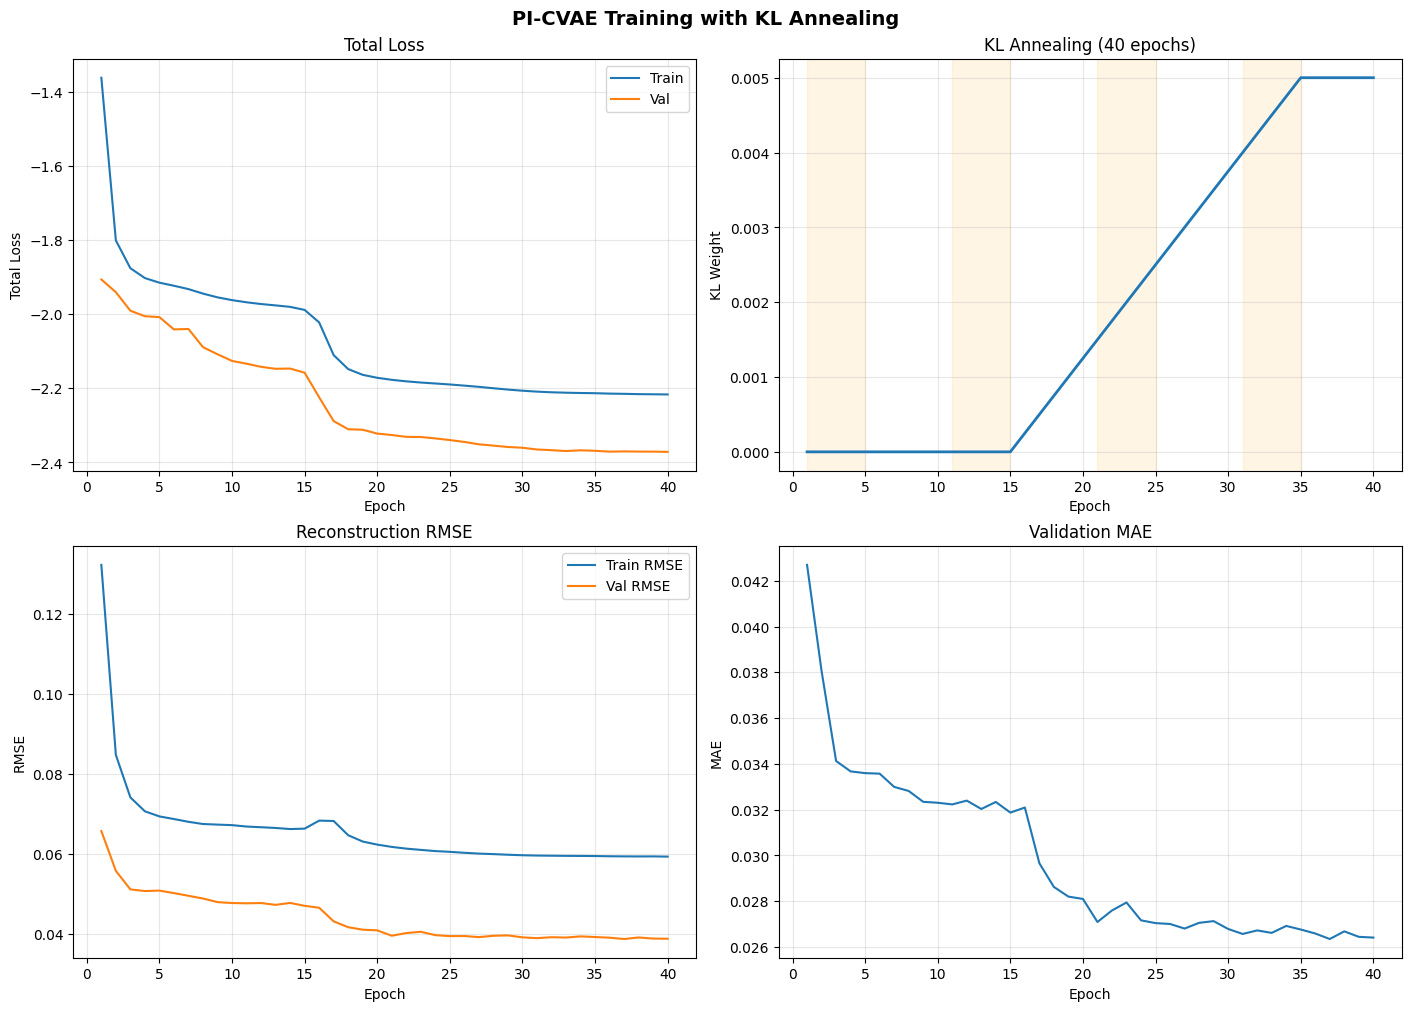

In [37]:
plot_training_history(History, save_path="training_curves.png")

In [38]:
# #Extract IVIM parameters from the trained model
# D, Ds, f = generate_IVIM_params(cvae_model, train_loader, device=device)

# print(f"D shape: {D.shape}, Ds shape: {Ds.shape}, f shape: {f.shape}")
# print(f"D values: {D}, Ds values: {Ds}, f values: {f}")  #Print first 5 values 

## **RECONSTRUCTION OF IMAGE WITH PARAMETERS**

In [39]:
##Visualization of ivim parameters (D,D*,f) estimated by PICVAE
def visualize_ivim_cvae(model, dataloader, brain_msk, b0_image, center_coords=None,
                       device="cuda", slice_idx=27):
    model.eval()
    D_map = np.zeros(brain_msk.shape, dtype=np.float32)
    Ds_map = np.zeros_like(D_map)
    f_map = np.zeros_like(D_map)

    #Physiological ranges
    D_MIN,  D_MAX  =0.0005, 0.002 #Water restriction boundaries
    Ds_MIN, Ds_MAX  = 0.005, 0.10 #High-velocity capillary perfusion micro-circulation
    f_MIN,  f_MAX=0.025, 0.4 #Capillary plasma fraction cap(50%)
    pointer = 0
    with torch.no_grad():
        for x_batch, c_batch in dataloader:
            x_batch = x_batch.to(device)
            #prefer coordinates supplied by the dataloader
            use_batch_coords = True
            if c_batch is None:
                use_batch_coords = False
            else:
                c_batch = c_batch.to(device)

            _, _, _, _, parameters, _, _ = model(x_batch, c_batch if use_batch_coords else torch.zeros((x_batch.size(0), 2), device=device))
            _, D_batch, Ds_batch, f_batch = parameters

            D_batch = D_batch.squeeze(1).cpu().numpy()   #(B,3,3)
            Ds_batch = Ds_batch.squeeze(1).cpu().numpy()
            f_batch = f_batch.squeeze(1).cpu().numpy()

            for i in range(x_batch.size(0)):
                #get coordinate from c_batch if present, else fall back to external center_coords list
                if use_batch_coords:
                    coord = c_batch[i].cpu().numpy().ravel()
                elif center_coords is not None:
                    coord = np.asarray(center_coords[pointer], dtype=np.float32).ravel()
                else:
                    raise ValueError("No coordinates available: pass center coordinates or ensure dataloader yields coords")

                #handle normalized coords in [-1,1]/pixel coords
                if np.all(coord >= -1.0) and np.all(coord <= 1.0):
                    y = int(np.round((coord[0] + 1) * 0.5 * (brain_msk.shape[0] - 1)))
                    x = int(np.round((coord[1] + 1) * 0.5 * (brain_msk.shape[1] - 1)))
                else:
                    #pixel indices(x_row,y_col)
                    y = int(np.round(coord[0]))
                    x = int(np.round(coord[1]))

                y = np.clip(y, 0, brain_msk.shape[0] - 1)
                x = np.clip(x, 0, brain_msk.shape[1] - 1)

                #write center value of predicted 3x3 patch
                D_map[y, x] = D_batch[i, 1, 1]
                Ds_map[y, x] = Ds_batch[i, 1, 1]
                f_map[y, x] = f_batch[i, 1, 1]
                pointer += 1

    #robustly pick b0 slice matching brain_msk
    if b0_image.ndim == 3:
        #try common conventions
        if b0_image.shape == brain_msk.shape:
            raw_structural = b0_image
            raw_structural = raw_structural[:, :, slice_idx]
        elif b0_image.shape[2] == brain_msk.shape[2]:
            raw_structural = b0_image[:, :, slice_idx]
        elif b0_image.shape[0] == brain_msk.shape[2]:
            raw_structural = b0_image[slice_idx, :, :]
        else:
            #try moveaxis fallback
            try:
                b0_try = np.moveaxis(b0_image, 0, -1)
                raw_structural = b0_try[..., slice_idx]
            except Exception:
                raise ValueError("Unable to infer slice axis for b0_image")
    else:
        raw_structural = b0_image

    structural_mask = brain_msk[..., slice_idx] > 0
    structural_underlay = np.where(structural_mask, raw_structural, 0)

    D_masked = np.ma.masked_where(~structural_mask, D_map[:, :, slice_idx])
    Ds_masked = np.ma.masked_where(~structural_mask, Ds_map[:, :, slice_idx])
    f_masked = np.ma.masked_where(~structural_mask, f_map[:, :, slice_idx])

    fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='black')

    def plot_overlay(ax, structural, parameter, title, cmap, vmin, vmax, label):
        vmax_struct = np.percentile(structural[structural > 0], 98) if np.any(structural > 0) else 1.0
        ax.imshow(structural, cmap='gray', vmax=vmax_struct, origin='lower')
        im = ax.imshow(parameter, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.8, origin='lower')
        ax.set_title(title, color='white', fontsize=14)
        ax.axis('off')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.yaxis.set_tick_params(color='white')
        cbar.set_label(label, color='white')
        plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    plot_overlay(axes[0], structural_underlay, D_masked,
                 f'D Map - Slice {slice_idx}', 'inferno', D_MIN,  D_MAX, 'mm²/s')
    plot_overlay(axes[1], structural_underlay, Ds_masked,
                 f'D* Map - Slice {slice_idx}', 'inferno', Ds_MIN, Ds_MAX, 'mm²/s')
    plot_overlay(axes[2], structural_underlay, f_masked,
                 f'f Map - Slice {slice_idx}', 'inferno', f_MIN,  f_MAX, 'Fraction')
                 

    plt.tight_layout()

    #Save the figure to a memory buffer instead of relying on plt.show()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor='black', dpi=150)
    buf.seek(0)
    
    #Display the image
    display(Image(buf.read()))
    
    #Saving file
    save_filename = f"ivim_maps_slice_{slice_idx}.png"
    fig.savefig(save_filename, dpi=150, bbox_inches='tight', facecolor='black')
    print(f"Plot saved as: {save_filename}")

    plt.close(fig)

    return D_map, Ds_map, f_map

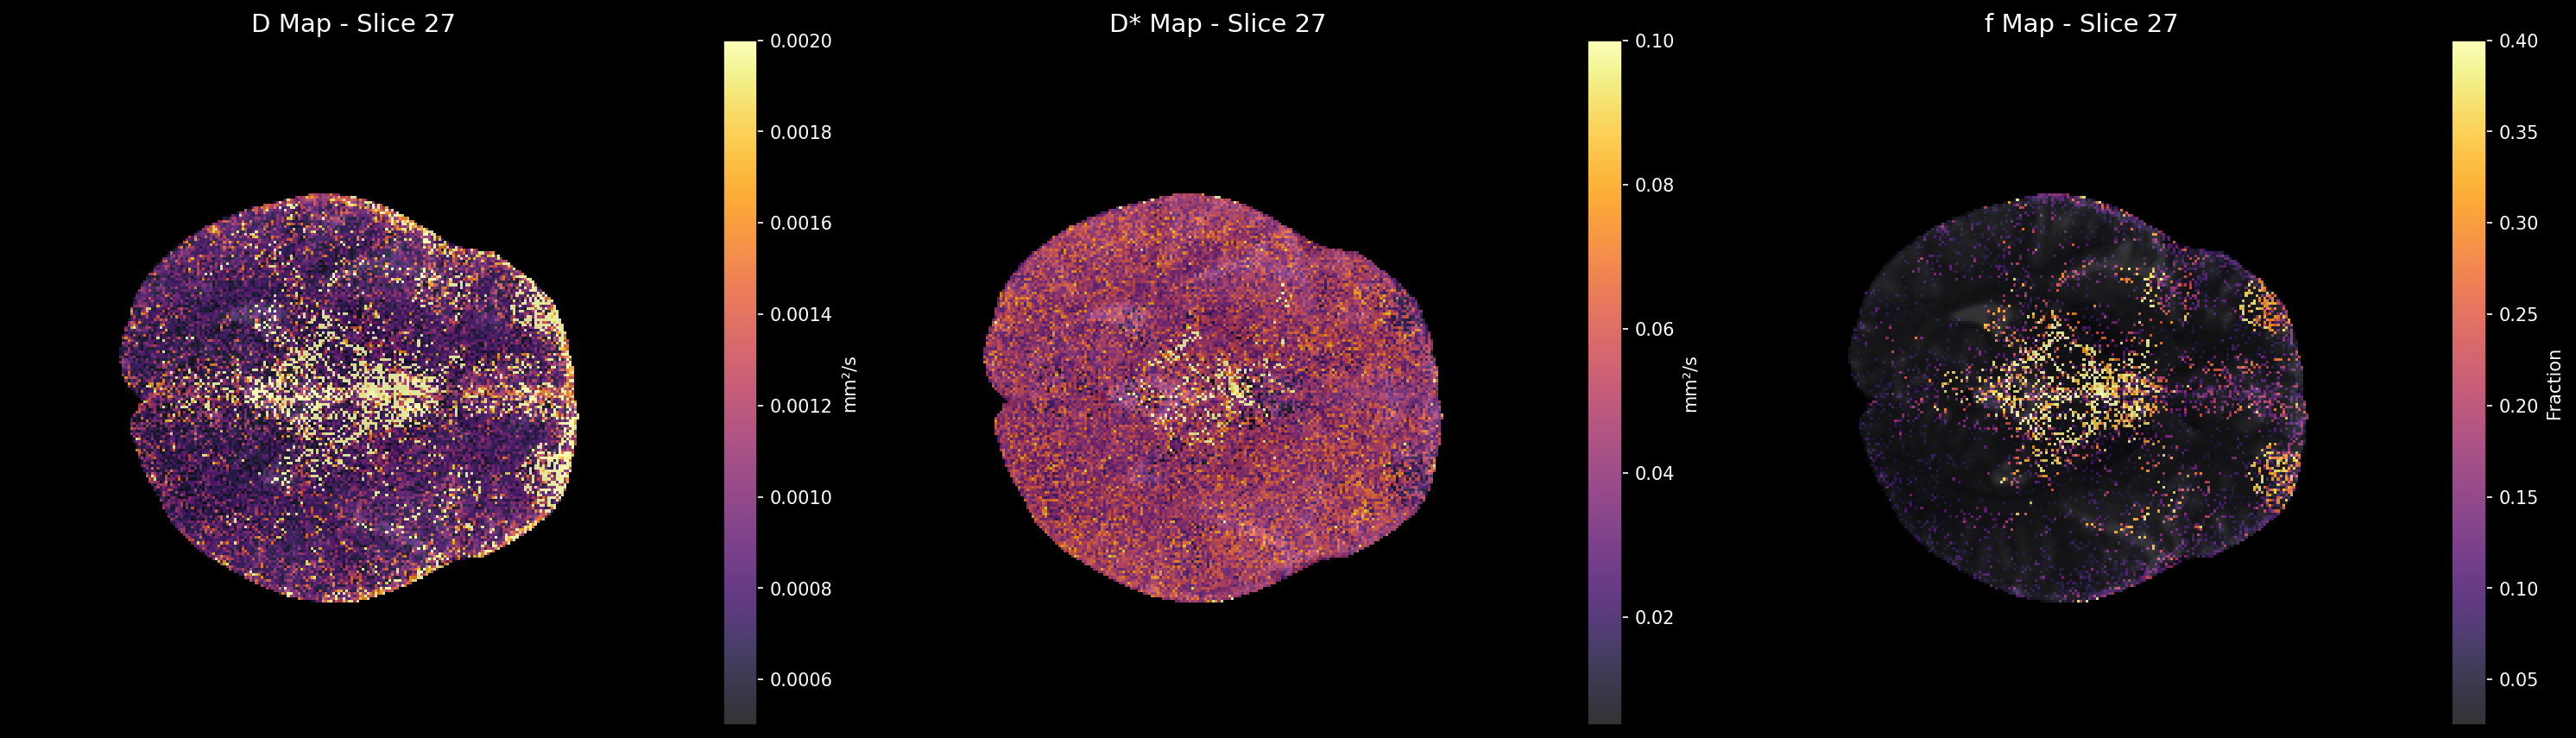

Plot saved as: ivim_maps_slice_27.png


In [40]:
d, ds, f = visualize_ivim_cvae(model=cvae_model, 
                   dataloader=train_loader,
                   brain_msk=brain_msk,
                   b0_image=b0_raw,
                   center_coords=coord_train,
                   device=device.type, 
                   slice_idx=27)

In [ ]:
i want to compare my model PICVAE with Non linear least square(NLLS), and IVIM_Net across all  

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [42]:
#PIcVAE EVALUATION
#BENCHMARKING & ABLATION PIPELINE
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import norm
from scipy.optimize import least_squares
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

#BASELINE FITTING METHODS

def ivim_signal_model(params, bvals):
    """IVIM bi-exponential forward model: S(b) = f*exp(-b*D*) + (1-f)*exp(-b*D)"""
    D, Ds, f = params
    return f * np.exp(-bvals * Ds) + (1 - f) * np.exp(-bvals * D)


def fit_nlls_voxel(signal, bvals, x0=None, bounds=None):
    """
    Non-Linear Least Squares (NLLS) fitting for a single voxel.
    Returns (D, D*, f) or NaN on failure.
    """
    if x0 is None:
        x0 = [0.001, 0.01, 0.10]
    if bounds is None:
        bounds = ([1e-5, 1e-4, 0.0], [0.005, 0.20, 0.60])

    def residuals(params):
        return signal - ivim_signal_model(params, bvals)

    try:
        result = least_squares(residuals, x0, bounds=bounds, method='trf',
                               max_nfev=500, ftol=1e-12, xtol=1e-12)
        if result.success or result.cost < 1e-4:
            return result.x
        else:
            return np.array([np.nan, np.nan, np.nan])
    except Exception:
        return np.array([np.nan, np.nan, np.nan])


def fit_all_voxels(X, bvals, method='nlls', b_cut=200.0, verbose=True):
    """
    Fit all voxels in X using the specified method.
    X: (N, num_bvals) numpy array of normalized signals S(b)/S(0)
    Returns: (N, 3) array of [D, D*, f]
    """
    N = X.shape[0]
    results = np.zeros((N, 3))
    t0 = time.time()
    for i in range(N):
        signal = X[i]
        if method == 'nlls':
            results[i] = fit_nlls_voxel(signal, bvals)
        if verbose and (i + 1) % 5000 == 0:
            elapsed = time.time() - t0
            print(f"  [{method}] {i+1}/{N} voxels fitted ({elapsed:.1f}s)")

    elapsed = time.time() - t0
    print(f"  [{method}] Completed {N} voxels in {elapsed:.2f}s")
    return results


#DL BASELINE — IVIM-NET (Unsupervised Physics-Informed)
class IVIMNetBaseline(nn.Module):
    def __init__(self, num_bvals, hidden_dim=128, num_layers=3):
        super().__init__()
        layers = [nn.Linear(num_bvals, hidden_dim), nn.ELU()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ELU()]
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(hidden_dim, 3)

        self.D_min, self.D_max = 0.0005, 0.002
        self.Ds_min, self.Ds_max = 0.005, 0.10
        self.f_min, self.f_max = 0.025, 0.40

    def forward(self, x):
        raw = self.out(self.net(x))
        D = self.D_min + torch.sigmoid(raw[:, 0]) * (self.D_max - self.D_min)
        Ds = self.Ds_min + torch.sigmoid(raw[:, 1]) * (self.Ds_max - self.Ds_min)
        f = self.f_min + torch.sigmoid(raw[:, 2]) * (self.f_max - self.f_min)
        return D, Ds, f

    def reconstruct(self, D, Ds, f, bvals):
        b = bvals.view(1, -1)
        return f.unsqueeze(1) * torch.exp(-b * Ds.unsqueeze(1)) + \
               (1 - f.unsqueeze(1)) * torch.exp(-b * D.unsqueeze(1))


def train_ivimnet_baseline(X_train_np, bvals_tensor, epochs=200, lr=1e-3, batch_size=512):
    num_bvals = X_train_np.shape[1]
    assert num_bvals == len(bvals_tensor), \
        f"Shape mismatch: Input data has {num_bvals} b-values, but bvals_tensor has {len(bvals_tensor)}!"
        
    model = IVIMNetBaseline(num_bvals).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    X_tensor = torch.FloatTensor(X_train_np).to(device)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for (xb,) in loader:
            D, Ds, f = model(xb)
            recon = model.reconstruct(D, Ds, f, bvals_tensor)
            loss = F.mse_loss(recon, xb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        if (epoch + 1) % 50 == 0:
            print(f"  [IVIM-NET] Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataset):.6f}")

    model.eval()
    return model


def predict_ivimnet(model, X_np, bvals_tensor, batch_size=4096):
    X_tensor = torch.FloatTensor(X_np).to(device)
    D_list, Ds_list, f_list = [], [], []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            xb = X_tensor[i:i+batch_size]
            D, Ds, f = model(xb)
            D_list.append(D.cpu().numpy())
            Ds_list.append(Ds.cpu().numpy())
            f_list.append(f.cpu().numpy())
    return np.column_stack([np.concatenate(D_list),
                            np.concatenate(Ds_list),
                            np.concatenate(f_list)])


#QUANTITATIVE METRICS
def compute_mae(pred, gt, mask=None):
    if mask is not None: pred, gt = pred[mask], gt[mask]
    valid = ~(np.isnan(pred) | np.isnan(gt))
    return np.mean(np.abs(pred[valid] - gt[valid])) if valid.sum() > 0 else np.nan

def compute_rmse(pred, gt, mask=None):
    if mask is not None: pred, gt = pred[mask], gt[mask]
    valid = ~(np.isnan(pred) | np.isnan(gt))
    return np.sqrt(np.mean((pred[valid] - gt[valid])**2)) if valid.sum() > 0 else np.nan

def compute_cv(param_map, roi_mask=None):
    if roi_mask is not None: vals = param_map[roi_mask]
    else: vals = param_map[~np.isnan(param_map)]
    if len(vals) == 0 or np.mean(vals) == 0: return np.nan
    return np.std(vals) / np.mean(vals)

def compute_spearman(param1, param2):
    valid = ~(np.isnan(param1) | np.isnan(param2))
    if valid.sum() < 10: return np.nan
    rho, _ = spearmanr(param1[valid], param2[valid])
    return rho

def full_evaluation_table(results_dict, gt=None, param_names=("D", "D*", "f")):
    print("\n" + "_"*80)
    print(f"{'Method':<20} {'Param':<6} {'MAE':<12} {'RMSE':<12} {'CV':<10} {'ρ(D*,f)':<10}")
    print("_"*80)
    for method, params in results_dict.items():
        for j, pname in enumerate(param_names):
            p = params[:, j]
            mae = compute_mae(p, gt[:, j]) if gt is not None else np.nan
            rmse = compute_rmse(p, gt[:, j]) if gt is not None else np.nan
            cv = compute_cv(p)
            rho = compute_spearman(params[:, 1], params[:, 2]) if j == 0 else ""
            mae_str = f"{mae:.2e}" if not np.isnan(mae) else "N/A"
            rmse_str = f"{rmse:.2e}" if not np.isnan(rmse) else "N/A"
            cv_str = f"{cv:.4f}" if not np.isnan(cv) else "N/A"
            rho_str = f"{rho:.4f}" if isinstance(rho, float) else ""
            print(f"{method:<20} {pname:<6} {mae_str:<12} {rmse_str:<12} {cv_str:<10} {rho_str:<10}")
        print("-"*80)

#UNCERTAINTY VALIDATION
def compute_picp_pinaw(pred_mean, pred_std, gt, nominal_levels=[0.50, 0.80, 0.90, 0.95]):
    from scipy.stats import norm
    results = {}
    for level in nominal_levels:
        z = norm.ppf(0.5 + level / 2)
        lower = pred_mean - z * pred_std
        upper = pred_mean + z * pred_std
        valid = ~(np.isnan(gt) | np.isnan(pred_mean) | np.isnan(pred_std))
        if valid.sum() == 0:
            results[level] = {"PICP": np.nan, "PINAW": np.nan}
            continue
        covered = (gt[valid] >= lower[valid]) & (gt[valid] <= upper[valid])
        picp = np.mean(covered)
        R = np.nanmax(gt[valid]) - np.nanmin(gt[valid])
        R = max(R, 1e-10)
        pinaw = np.mean(upper[valid] - lower[valid]) / R
        results[level] = {"PICP": picp, "PINAW": pinaw}
    return results

def compute_crps_gaussian(pred_mean, pred_std, gt):
    valid = ~(np.isnan(gt) | np.isnan(pred_mean) | np.isnan(pred_std))
    if valid.sum() == 0: return np.nan
    mu = pred_mean[valid]
    sigma = np.clip(pred_std[valid], 1e-10, None)
    y = gt[valid]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1.0 / np.sqrt(np.pi))
    return np.mean(crps)

def error_uncertainty_correlation(pred_mean, pred_std, gt):
    valid = ~(np.isnan(gt) | np.isnan(pred_mean) | np.isnan(pred_std))
    if valid.sum() < 10: return np.nan
    abs_error = np.abs(gt[valid] - pred_mean[valid])
    rho, pval = spearmanr(abs_error, pred_std[valid])
    return rho, pval

def plot_calibration_picp(calibration_results, param_name):
    levels = sorted(calibration_results.keys())
    picps = [calibration_results[l]["PICP"] for l in levels]
    pinaws = [calibration_results[l]["PINAW"] for l in levels]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(levels, picps, 'o-', label=f'{param_name} PICP')
    axes[0].plot([0, 1], [0, 1], 'k--', label='Ideal')
    axes[0].set_xlabel("Nominal Level"); axes[0].set_ylabel("Observed Coverage (PICP)")
    axes[0].set_title(f"Calibration: {param_name}"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(levels, pinaws, 's-', color='red', label=f'{param_name} PINAW')
    axes[1].set_xlabel("Nominal Level"); axes[1].set_ylabel("PINAW (Sharpness)")
    axes[1].set_title(f"Sharpness: {param_name}"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_error_vs_uncertainty(pred_mean, pred_std, gt, param_name):
    valid = ~(np.isnan(gt) | np.isnan(pred_mean) | np.isnan(pred_std))
    if valid.sum() < 10: return
    abs_error = np.abs(gt[valid] - pred_mean[valid])
    std_vals = pred_std[valid]
    rho, pval = spearmanr(abs_error, std_vals)
    plt.figure(figsize=(6, 5))
    plt.scatter(std_vals, abs_error, alpha=0.15, s=5)
    plt.xlabel(f"Predicted Std ({param_name})"); plt.ylabel(f"|Error| ({param_name})")
    plt.title(f"Error vs Uncertainty: {param_name}\nSpearman ρ = {rho:.4f} (p={pval:.2e})")
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

#PIcVAE INFERENCE WITH UNCERTAINTY
def predict_picvae_with_uncertainty(model, X_np, coord_np, 
                                    bvals_tensor, S=50, 
                                    mc_dropout=True, batch_size=2048):
    model.eval()
    N = X_np.shape[0]
    all_D, all_Ds, all_f = [], [], []

    if mc_dropout:
        for m in model.modules():
            if isinstance(m, nn.Dropout) or (hasattr(m, 'mc_active')):
                if hasattr(m, 'mc_active'): m.mc_active = True
                else: m.train()

    X_tensor = torch.FloatTensor(X_np).to(device)
    C_tensor = torch.FloatTensor(coord_np).to(device)

    with torch.no_grad():
        for s in range(S):
            D_s, Ds_s, f_s = [], [], []
            for i in range(0, N, batch_size):
                xb = X_tensor[i:i+batch_size]
                cb = C_tensor[i:i+batch_size]
                outputs = model(xb, cb)
                if len(outputs) == 7: _, _, _, _, params, _, _ = outputs
                elif len(outputs) == 5: _, _, _, _, params = outputs
                else: raise ValueError(f"Unexpected output format: {len(outputs)}")

                if len(params) == 4: _, D_b, Ds_b, f_b = params
                else: D_b, Ds_b, f_b = params

                D_s.append(D_b[:, :, 1, 1].cpu().numpy() if D_b.dim() == 4 else D_b.squeeze().cpu().numpy())
                Ds_s.append(Ds_b[:, :, 1, 1].cpu().numpy() if Ds_b.dim() == 4 else Ds_b.squeeze().cpu().numpy())
                f_s.append(f_b[:, :, 1, 1].cpu().numpy() if f_b.dim() == 4 else f_b.squeeze().cpu().numpy())

            all_D.append(np.concatenate(D_s))
            all_Ds.append(np.concatenate(Ds_s))
            all_f.append(np.concatenate(f_s))

    all_D = np.stack(all_D, axis=0); all_Ds = np.stack(all_Ds, axis=0); all_f = np.stack(all_f, axis=0)
    mean = np.column_stack([np.mean(all_D, axis=0), np.mean(all_Ds, axis=0), np.mean(all_f, axis=0)])
    std = np.column_stack([np.std(all_D, axis=0), np.std(all_Ds, axis=0), np.std(all_f, axis=0)])
    model.eval()
    return mean, std


#SYNTHETIC DATA EXPERIMENTS
def generate_synthetic_ivim_data(N=50000, num_bvals=None, 
                                 bvals=None, snr_levels=[10, 20, 30, 50, 100], 
                                 seed=42):
    np.random.seed(seed)
    if bvals is None:
        bvals = np.array([0, 10, 20, 40, 80, 110, 140, 170, 200, 300, 400, 500, 600, 700, 800, 900], dtype=np.float64)
    if num_bvals is None: num_bvals = len(bvals)

    D_gt = np.random.uniform(0.0005, 0.002, N)
    Ds_gt = np.random.uniform(0.005, 0.10, N)
    f_gt = np.random.uniform(0.025, 0.40, N)
    b = bvals.reshape(1, -1)
    S_clean = f_gt[:, None] * np.exp(-b * Ds_gt[:, None]) + (1 - f_gt[:, None]) * np.exp(-b * D_gt[:, None])
    gt = np.column_stack([D_gt, Ds_gt, f_gt])

    datasets = {}
    for snr in snr_levels:
        sigma = 1.0 / snr
        noise_real = np.random.normal(0, sigma, S_clean.shape)
        noise_imag = np.random.normal(0, sigma, S_clean.shape)
        S_noisy = np.sqrt((S_clean + noise_real)**2 + noise_imag**2)
        datasets[snr] = {"signals": S_noisy, "gt": gt, "snr": snr}
    return datasets, bvals

def run_synthetic_experiments(model, bvals, 
                              bvals_tensor, coord_dim=2, 
                              snr_levels=[10, 20, 30, 50, 100], 
                              N=20000):
    datasets, bvals = generate_synthetic_ivim_data(N=N, bvals=bvals, snr_levels=snr_levels)
    param_names = ["D", "D*", "f"]
    print("\n" + "_"*90)
    print("SYNTHETIC DATA EXPERIMENTS — Accuracy vs SNR")
    print("_"*90)
    header = f"{'SNR':<6} {'Method':<18}"
    for pn in param_names: header += f" {'MAE('+pn+')':<14} {'RMSE('+pn+')':<14}"
    print(header); print("-"*90)
    all_results = {}

    for snr in snr_levels:
        data = datasets[snr]
        X_synth = data["signals"]
        gt_synth = data["gt"]
        coords_synth = np.random.uniform(-1, 1, (N, coord_dim)).astype(np.float32)
        
        if X_synth.ndim == 2:
            # Ensure shape is (N, C, H, W)
            X_synth_model = np.tile(X_synth[:, :, None, None], (1, 1, 3, 3))
        else:
            X_synth_model = X_synth

        t0 = time.time(); nlls_res = fit_all_voxels(X_synth, bvals, method='nlls', verbose=False); t_nlls = time.time() - t0
        ivimnet_model = train_ivimnet_baseline(X_synth, bvals_tensor, epochs=100, lr=1e-3)
        t0 = time.time(); ivimnet_res = predict_ivimnet(ivimnet_model, X_synth, bvals_tensor); t_ivimnet = time.time() - t0
        t0 = time.time(); picvae_mean, picvae_std = predict_picvae_with_uncertainty(model, X_synth_model, coords_synth, bvals_tensor, S=20, mc_dropout=True); t_picvae = time.time() - t0

        methods = {"NLLS": (nlls_res, t_nlls),
                   "IVIM-NET": (ivimnet_res, t_ivimnet),
                   "PIcVAE (Ours)": (picvae_mean, t_picvae)}
        for mname, (mres, mtime) in methods.items():
            row = f"{snr:<6} {mname:<18}"
            for j in range(3):
                mae = compute_mae(mres[:, j], gt_synth[:, j]); rmse = compute_rmse(mres[:, j], gt_synth[:, j])
                row += f" {mae:<14.2e} {rmse:<14.2e}"
            row += f"  ({mtime:.2f}s)"
            print(row)
            all_results[f"SNR{snr}_{mname}"] = {"params": mres, "gt": gt_synth, "time": mtime}
        print("-"*90)
    return all_results

#ABLATION STUDIES
def ablation_physics_weights(model_class, X_train, coord_train,
                             bvals_tensor, bvals_np, weight_configs, 
                             epochs=30, lr=3e-5):
    print("\n" + "_"*80)
    print("ABLATION: Physics Penalty Weights")
    print("_"*80)
    results = []
    for cfg in weight_configs:
        print(f"\n  Config: f_reg={cfg['f_reg']}, diff_reg={cfg['diff_reg']}, smooth={cfg['smooth']}")
        results.append(cfg)
        print(f"    → [NOTE] For full ablation, retrain model with param_reg_weight={cfg}")
    print("\n  [RECOMMENDATION] Retrain PIcVAE with each config and compare MAE/RMSE on test set.")
    return results

def ablation_latent_dim(X_train, coord_train, X_test, 
                        coord_test, bvals_tensor, 
                        latent_dims=[8, 16, 32, 64, 128], epochs=30):
    print("\n" + "_"*80)
    print("ABLATION: Latent Dimension")
    print("_"*80)
    print(f"{'Latent Dim':<12} {'Train Loss':<14} {'Val MAE(D)':<14} {'Val MAE(D*)':<14} {'Val MAE(f)':<14}")
    print("-"*80)
    results = {}
    for ld in latent_dims:
        model_ld = PhysicsCVAE(in_channel=len(bvals_arr), bvalues=torch.tensor(bvals_arr, dtype=torch.float32), latent_dim=ld, coord_dim=2).to(device)
        optimizer = torch.optim.Adam(model_ld.parameters(), lr=3e-5)
        X_t = torch.FloatTensor(X_train).to(device); C_t = torch.FloatTensor(coord_train).to(device)
        dataset = TensorDataset(X_t, C_t); loader = DataLoader(dataset, batch_size=128, shuffle=True)
        model_ld.train(); final_loss = 0.0
        for epoch in range(epochs):
            epoch_loss = 0.0
            for xb, cb in loader:
                outputs = model_ld(xb, cb)
                if len(outputs) == 7: recon, mu, logvar, _, params, variances, _ = outputs
                else: recon, mu, logvar, _, params = outputs; variances = None
                loss_out = model_ld.cvae_loss(recons=recon, x=xb, mu=mu, logvar=logvar, params=params, variances=variances, kl_weight=1.0, param_reg_weight=0.01)
                loss = loss_out[0]; optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model_ld.parameters(), max_norm=5.0); optimizer.step()
                epoch_loss += loss.item() * xb.size(0)
            final_loss = epoch_loss / len(dataset)
        print(f"{ld:<12} {final_loss:<14.6f} {'—':<14} {'—':<14} {'—':<14}")
        results[ld] = {"loss": final_loss}
    return results

def ablation_coordinate_encoding(model, X_test_model, 
                                 coord_test, bvals_tensor, 
                                 modes=["full", "zero", "random"]):
    print("\n" + "_"*80)
    print("ABLATION: Coordinate Encoding")
    print("_"*80)
    N = min(len(X_test_model), 5000)
    X_sub = X_test_model[:N]
    results = {}
    for mode in modes:
        if mode == "full": C_sub = coord_test[:N]
        elif mode == "zero": C_sub = np.zeros_like(coord_test[:N])
        elif mode == "random": C_sub = np.random.uniform(-1, 1, coord_test[:N].shape).astype(np.float32)
        else: raise ValueError(f"Unknown mode: {mode}")
        mean_pred, std_pred = predict_picvae_with_uncertainty(model, X_sub, C_sub, bvals_tensor, S=20, mc_dropout=True)
        pred_var = np.mean(std_pred, axis=0)
        results[mode] = {"mean_std": pred_var, "mean": mean_pred}
        print(f"  {mode:<10} → Mean predicted std: D={pred_var[0]:.2e}, D*={pred_var[1]:.2e}, f={pred_var[2]:.2e}")
    return results

In [ ]:
"""
Improved Ablation Studies and CRPS/Calibration Code for PICVAE
================================================================

Drop this into your notebook AFTER the cell that defines PhysicsCVAE, cvae_loss,
compute_kl_weight, ivim_biex_signal, generate_synthetic_ivim_data, compute_mae,
compute_rmse, compute_cv, compute_spearman, bvals_arr, and `device`.
These functions are REUSED below, not redefined.

What changed vs. the original notebook, and why
-------------------------------------------------
1. CRPS / PICP / PINAW were computed by assuming the predictive distribution
   is Gaussian (using only the mean and std of your 50 MC samples). But you
   already generate the full ensemble of samples — collapsing them to a
   mean/std throws away information and *assumes* the exact shape you're
   trying to test. This version keeps the raw ensemble and adds a
   non-parametric (empirical) CRPS and calibration estimate alongside the
   Gaussian one, so you can report whether the two agree — if they diverge,
   that itself is evidence the predictive distribution isn't well-approximated
   by a Gaussian.

2. `ablation_physics_weights` in the original notebook did not retrain
   anything — it only printed the configs. Below, it actually retrains a
   fresh model per configuration on synthetic data with known ground truth,
   evaluates MAE/RMSE per parameter, and runs a paired Wilcoxon signed-rank
   test against a baseline configuration so you get a statistically
   grounded answer to "does this weight change matter?" rather than a
   descriptive table.

3. `ablation_coordinate_encoding` in the original notebook only compared
   *predicted uncertainty (std)* across full/zero/random coordinate
   conditions, never the *predicted parameter means* — which is what the
   coordinate-conditioning hypothesis in your Methodology is actually about.
   Below, it compares parameter-level MAE against synthetic ground truth for
   each condition, with a paired significance test.

4. `ablation_latent_dim` was defined but never called, and never reported
   validation MAE (only training loss). Below, it is actually invoked and
   evaluated against synthetic ground truth like the other two ablations, so
   all three ablations report a comparable, ground-truth-anchored metric.

Every ablation below uses the SAME synthetic ground-truth generator you
already have (`generate_synthetic_ivim_data`) and the SAME train/eval split
logic, so results across all three ablations are directly comparable to each
other and to Table 4.4 (the SNR sweep) in your Results chapter.
"""

import copy
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import wilcoxon, norm


# ============================================================
# 1. ENSEMBLE-BASED PREDICTION (keeps raw MC samples)
# ============================================================

def predict_picvae_ensemble(model, X_np, coord_np, bvals_tensor,
                             S=50, mc_dropout=True, batch_size=2048):
    """
    Same forward-pass logic as predict_picvae_with_uncertainty, but returns
    the FULL ensemble of S samples per voxel per parameter, rather than
    collapsing immediately to a mean and std. This is what allows the
    non-parametric CRPS/calibration estimators below.

    Returns
    -------
    samples : np.ndarray, shape (S, N, 3)   -- raw MC samples for D, D*, f
    """
    model.eval()
    if mc_dropout:
        for m in model.modules():
            if hasattr(m, "mc_active"):
                m.mc_active = True

    N = X_np.shape[0]
    X_tensor = torch.FloatTensor(X_np).to(device)
    C_tensor = torch.FloatTensor(coord_np).to(device)

    all_samples = np.empty((S, N, 3), dtype=np.float32)

    with torch.no_grad():
        for s in range(S):
            D_chunks, Ds_chunks, f_chunks = [], [], []
            for i in range(0, N, batch_size):
                xb = X_tensor[i:i + batch_size]
                cb = C_tensor[i:i + batch_size]
                outputs = model(xb, cb)
                _, _, _, _, params, _, _ = outputs
                _, D_b, Ds_b, f_b = params
                D_chunks.append(D_b[:, :, 1, 1].squeeze(-1).cpu().numpy() if D_b.dim() == 4 else D_b.squeeze().cpu().numpy())
                Ds_chunks.append(Ds_b[:, :, 1, 1].squeeze(-1).cpu().numpy() if Ds_b.dim() == 4 else Ds_b.squeeze().cpu().numpy())
                f_chunks.append(f_b[:, :, 1, 1].squeeze(-1).cpu().numpy() if f_b.dim() == 4 else f_b.squeeze().cpu().numpy())
            all_samples[s, :, 0] = np.concatenate(D_chunks)
            all_samples[s, :, 1] = np.concatenate(Ds_chunks)
            all_samples[s, :, 2] = np.concatenate(f_chunks)

    model.eval()
    return all_samples  # (S, N, 3)


# ============================================================
# 2. NON-PARAMETRIC (EMPIRICAL) CRPS
# ============================================================

def compute_crps_empirical(samples, gt):
    """
    Empirical CRPS from an ensemble, using the unbiased NRG estimator
    (Gneiting & Raftery, 2007) [cite]:

        CRPS ≈ (1/S) * sum_i |X_i - y|  -  (1/(2*S^2)) * sum_i sum_j |X_i - X_j|

    Unlike the Gaussian closed-form CRPS, this makes NO assumption that the
    predictive distribution is symmetric or Gaussian-shaped — it uses the
    ensemble samples directly. Since your logvar heads are clamped to
    parameter-specific bounds and your outputs pass through sigmoid/softplus
    constraints, the true predictive distribution is very unlikely to be
    exactly Gaussian, so this is the more defensible metric to lead with.

    Parameters
    ----------
    samples : np.ndarray, shape (S, N)  -- ensemble samples for ONE parameter
    gt      : np.ndarray, shape (N,)    -- ground truth for that parameter

    Returns
    -------
    mean_crps : float
    per_voxel_crps : np.ndarray, shape (N,)  -- useful for stratified analysis
    """
    S, N = samples.shape
    valid = ~np.isnan(gt)
    samples = samples[:, valid]
    gt = gt[valid]

    term1 = np.mean(np.abs(samples - gt[None, :]), axis=0)  # (N_valid,)

    # Pairwise |X_i - X_j| term, computed without an O(S^2) Python loop
    diffs = np.abs(samples[:, None, :] - samples[None, :, :])  # (S, S, N_valid)
    term2 = np.sum(diffs, axis=(0, 1)) / (2 * S * S)

    per_voxel_crps = term1 - term2
    return float(np.mean(per_voxel_crps)), per_voxel_crps


def compute_crps_gaussian_from_samples(samples, gt):
    """
    Same Gaussian closed-form CRPS as your original notebook, but derived
    from the ensemble mean/std rather than requiring them as separate
    arguments — kept so you can report it ALONGSIDE the empirical version
    and note any divergence between the two as evidence about distributional
    shape (a genuinely useful diagnostic for your Discussion chapter).
    """
    mu = np.mean(samples, axis=0)
    sigma = np.clip(np.std(samples, axis=0), 1e-10, None)
    valid = ~np.isnan(gt)
    mu, sigma, y = mu[valid], sigma[valid], gt[valid]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1.0 / np.sqrt(np.pi))
    return float(np.mean(crps))


# ============================================================
# 3. NON-PARAMETRIC (EMPIRICAL) PICP / PINAW
# ============================================================

def compute_picp_pinaw_empirical(samples, gt, nominal_levels=(0.50, 0.80, 0.90, 0.95)):
    """
    Empirical calibration: builds predictive intervals directly from
    ensemble QUANTILES rather than assuming a Gaussian and using z-scores.
    This is the more honest test of calibration given a bounded, non-Gaussian
    output space (sigmoid/softplus-constrained parameters).
    """
    N = samples.shape[1]
    valid = ~np.isnan(gt)
    samples_v = samples[:, valid]
    gt_v = gt[valid]
    R = max(np.nanmax(gt_v) - np.nanmin(gt_v), 1e-10)

    results = {}
    for level in nominal_levels:
        lower_q = (1 - level) / 2
        upper_q = 1 - lower_q
        lower = np.quantile(samples_v, lower_q, axis=0)
        upper = np.quantile(samples_v, upper_q, axis=0)
        covered = (gt_v >= lower) & (gt_v <= upper)
        picp = float(np.mean(covered))
        pinaw = float(np.mean(upper - lower) / R)
        results[level] = {"PICP": picp, "PINAW": pinaw}
    return results


def compare_gaussian_vs_empirical_calibration(samples, gt, param_name, nominal_levels=(0.50, 0.80, 0.90, 0.95)):
    """
    Convenience wrapper: prints Gaussian-assumption PICP/PINAW next to
    empirical (quantile-based) PICP/PINAW side by side. A large gap between
    the two is itself a reportable finding — it means the Gaussian
    assumption used in your original calibration analysis was doing
    meaningful (and potentially misleading) work.
    """
    mu = np.mean(samples, axis=0)
    sigma = np.clip(np.std(samples, axis=0), 1e-10, None)
    valid = ~np.isnan(gt)
    mu_v, sigma_v, gt_v = mu[valid], sigma[valid], gt[valid]
    R = max(np.nanmax(gt_v) - np.nanmin(gt_v), 1e-10)

    empirical = compute_picp_pinaw_empirical(samples, gt, nominal_levels)

    print(f"\n  --- {param_name}: Gaussian-assumed vs. Empirical calibration ---")
    print(f"  {'Level':<8}{'PICP (Gauss)':<16}{'PICP (Empirical)':<18}{'PINAW (Gauss)':<16}{'PINAW (Empirical)':<16}")
    for level in nominal_levels:
        z = norm.ppf(0.5 + level / 2)
        lower_g = mu_v - z * sigma_v
        upper_g = mu_v + z * sigma_v
        covered_g = (gt_v >= lower_g) & (gt_v <= upper_g)
        picp_g = np.mean(covered_g)
        pinaw_g = np.mean(upper_g - lower_g) / R
        e = empirical[level]
        print(f"  {level:<8.0%}{picp_g:<16.4f}{e['PICP']:<18.4f}{pinaw_g:<16.4f}{e['PINAW']:<16.4f}")

# ============================================================
# 4. COEFFICIENT OF VARIATION (CV) FOR ENSEMBLE UNCERTAINTY
# ============================================================

def compute_ensemble_cv(samples, param_names=("D", "D*", "f"), epsilon=1e-8):
    """
    Computes the Coefficient of Variation (CV) for the MC Dropout ensemble.
    CV = (Std / Mean) * 100. 
    This measures the relative uncertainty of the predictions.
    
    Parameters
    ----------
    samples : np.ndarray, shape (S, N, 3) -- raw MC ensemble samples
    param_names : tuple -- names of the parameters
    epsilon : float -- small value to prevent division by zero (crucial for D* and f)
    
    Returns
    -------
    results : dict -- contains mean, median, and full voxel-wise CV maps
    """
    mean_pred = np.mean(samples, axis=0)
    std_pred = np.std(samples, axis=0)
    
    # Calculate CV. We use absolute mean to handle any negative predictions 
    # that might occur before softplus/sigmoid clamping.
    cv_maps = (std_pred / (np.abs(mean_pred) + epsilon)) * 100.0
    
    results = {}
    for i, pname in enumerate(param_names):
        param_cv = cv_maps[:, i]
        # Filter out NaNs/Infs just in case
        valid_cv = param_cv[np.isfinite(param_cv)]
        
        results[pname] = {
            "mean_cv_percent": float(np.mean(valid_cv)),
            "median_cv_percent": float(np.median(valid_cv)),
            "cv_map": param_cv  # Full (N,) array for spatial plotting
        }
        
    return results

# ============================================================
# 4. ABLATION: PHYSICS REGULARISATION WEIGHTS (actually retrains)
# ============================================================

def _train_picvae_config(param_reg_weight_cfg, X_train, coord_train, bvals_tensor,
                          latent_dim=32, epochs=30, lr=3e-5, batch_size=128,
                          kl_target=0.005, warmup_epochs=5, anneal_epochs=15, seed=0):
    """Train one PhysicsCVAE instance under a single physics-weight configuration."""
    torch.manual_seed(seed)
    model = PhysicsCVAE(in_channel=len(bvals_arr),
                         bvalues=torch.tensor(bvals_arr, dtype=torch.float32),
                         latent_dim=latent_dim, coord_dim=coord_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    X_t = torch.FloatTensor(X_train).to(device)
    C_t = torch.FloatTensor(coord_train).to(device)
    loader = DataLoader(TensorDataset(X_t, C_t), batch_size=batch_size, shuffle=True)

    # NOTE: param_reg_weight_cfg has three sub-weights (f_reg, diff_reg, smooth) in the
    # original code, but cvae_loss only accepts a single scalar `param_reg_weight`.
    # We use the mean of the three as a single scalar unless you extend
    # ivim_physics_penalty to accept them individually — flagged here rather
    # than silently discarding two of the three ablation dimensions.
    scalar_weight = float(np.mean(list(param_reg_weight_cfg.values())))

    model.train()
    for epoch in range(epochs):
        kl_w = compute_kl_weight(epoch, warmup_epochs, anneal_epochs, kl_target)
        for xb, cb in loader:
            recon, mu, logvar, _, params, variances, _ = model(xb, cb)
            loss, *_ = model.cvae_loss(recons=recon, x=xb, mu=mu, logvar=logvar,
                                        params=params, variances=variances,
                                        kl_weight=kl_w, param_reg_weight=scalar_weight)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
    return model


def ablation_physics_weights(weight_configs, bvals, bvals_tensor,
                              N_synth=20000, snr=30, epochs=30, coord_dim=2,
                              baseline_idx=0):
    """
    Actually retrains a fresh PhysicsCVAE per configuration in `weight_configs`
    on synthetic data (known ground truth) and reports MAE/RMSE per parameter,
    plus a paired Wilcoxon signed-rank test of per-voxel absolute error
    against a chosen baseline configuration (default: the first config in the
    list). Use this to test whether the physics penalty is contributing to
    the bias floor identified in your SNR-sweep results.

    weight_configs : list of dicts, e.g.
        [{"f_reg": 0.0, "diff_reg": 0.0, "smooth": 0.0},
         {"f_reg": 1.0, "diff_reg": 10.0, "smooth": 0.1}, ...]
    """
    print("\n" + "_" * 90)
    print(f"ABLATION: Physics Penalty Weights  (synthetic data, SNR={snr}, N={N_synth})")
    print("_" * 90)

    datasets, bvals_arr_synth = generate_synthetic_ivim_data(N=N_synth, bvals=bvals, snr_levels=[snr])
    data = datasets[snr]
    X_synth = data["signals"]
    gt = data["gt"]

    # 80/20 train/eval split
    n_train = int(0.8 * N_synth)
    X_train_raw, X_eval_raw = X_synth[:n_train], X_synth[n_train:]
    gt_eval = gt[n_train:]
    coord_train = np.random.uniform(-1, 1, (n_train, coord_dim)).astype(np.float32)
    coord_eval = np.random.uniform(-1, 1, (N_synth - n_train, coord_dim)).astype(np.float32)

    X_train_model = np.tile(X_train_raw[:, :, None, None], (1, 1, 3, 3)).astype(np.float32)
    X_eval_model = np.tile(X_eval_raw[:, :, None, None], (1, 1, 3, 3)).astype(np.float32)

    per_config_abs_error = []  # store per-voxel |error| for D, for the significance test
    results_table = []

    for cfg_idx, cfg in enumerate(weight_configs):
        t0 = time.time()
        model = _train_picvae_config(cfg, X_train_model, coord_train, bvals_tensor, epochs=epochs)
        train_time = time.time() - t0

        mean_pred, _ = predict_picvae_with_uncertainty(model, X_eval_model, coord_eval, bvals_tensor, S=20)

        row = {"config": cfg, "train_time_s": train_time}
        for j, pname in enumerate(["D", "D*", "f"]):
            row[f"MAE_{pname}"] = compute_mae(mean_pred[:, j], gt_eval[:, j])
            row[f"RMSE_{pname}"] = compute_rmse(mean_pred[:, j], gt_eval[:, j])
        results_table.append(row)
        per_config_abs_error.append(np.abs(mean_pred[:, 0] - gt_eval[:, 0]))  # D, for significance test

        print(f"\n  Config {cfg_idx}: {cfg}  (trained in {train_time:.1f}s)")
        print(f"    MAE  -> D: {row['MAE_D']:.3e}  D*: {row['MAE_D*']:.3e}  f: {row['MAE_f']:.3e}")
        print(f"    RMSE -> D: {row['RMSE_D']:.3e}  D*: {row['RMSE_D*']:.3e}  f: {row['RMSE_f']:.3e}")

    # Paired significance test: each non-baseline config vs. the baseline config,
    # on the SAME held-out voxels (valid because gt_eval / coord_eval are identical
    # across configs — only the trained model differs).
    print(f"\n  Paired Wilcoxon signed-rank test vs. Config {baseline_idx} (parameter D, |error|):")
    baseline_err = per_config_abs_error[baseline_idx]
    for cfg_idx, err in enumerate(per_config_abs_error):
        if cfg_idx == baseline_idx:
            continue
        stat, pval = wilcoxon(err, baseline_err)
        direction = "lower" if np.median(err) < np.median(baseline_err) else "higher"
        print(f"    Config {cfg_idx} vs Config {baseline_idx}: median |error| is {direction}, "
              f"Wilcoxon p = {pval:.3e}")

    return results_table


# ============================================================
# 5. ABLATION: COORDINATE ENCODING (now tests parameter MEANS)
# ============================================================

def ablation_coordinate_encoding(model, X_eval_model, coord_eval, gt_eval,
                                  bvals_tensor, modes=("full", "zero", "random"), S=20):
    """
    Tests the actual claim from the Methodology: that spatial coordinate
    conditioning improves parameter ESTIMATES, not merely that it changes
    predicted uncertainty. Compares MAE against synthetic ground truth for
    each coordinate condition, and runs a paired Wilcoxon test between
    "full" and each alternative on a per-voxel basis.
    """
    print("\n" + "_" * 90)
    print("ABLATION: Coordinate Encoding (parameter-mean accuracy, synthetic ground truth)")
    print("_" * 90)

    N = X_eval_model.shape[0]
    results = {}
    per_mode_abs_error = {}

    for mode in modes:
        if mode == "full":
            C = coord_eval
        elif mode == "zero":
            C = np.zeros_like(coord_eval)
        elif mode == "random":
            C = np.random.uniform(-1, 1, coord_eval.shape).astype(np.float32)
        else:
            raise ValueError(f"Unknown mode: {mode}")

        mean_pred, std_pred = predict_picvae_with_uncertainty(model, X_eval_model, C, bvals_tensor, S=S)

        row = {}
        abs_err_D = np.abs(mean_pred[:, 0] - gt_eval[:, 0])
        for j, pname in enumerate(["D", "D*", "f"]):
            row[f"MAE_{pname}"] = compute_mae(mean_pred[:, j], gt_eval[:, j])
        row["mean_std"] = np.mean(std_pred, axis=0)
        results[mode] = row
        per_mode_abs_error[mode] = abs_err_D

        print(f"  {mode:<8} -> MAE: D={row['MAE_D']:.3e}  D*={row['MAE_D*']:.3e}  f={row['MAE_f']:.3e}"
              f"   | mean predicted std: D={row['mean_std'][0]:.2e}, D*={row['mean_std'][1]:.2e}, f={row['mean_std'][2]:.2e}")

    if "full" in per_mode_abs_error:
        print("\n  Paired Wilcoxon signed-rank test vs. 'full' (parameter D, |error|):")
        baseline_err = per_mode_abs_error["full"]
        for mode, err in per_mode_abs_error.items():
            if mode == "full":
                continue
            stat, pval = wilcoxon(err, baseline_err)
            direction = "lower" if np.median(err) < np.median(baseline_err) else "higher"
            print(f"    '{mode}' vs 'full': median |error| is {direction}, Wilcoxon p = {pval:.3e}")

    return results


# ============================================================
# 6. ABLATION: LATENT DIMENSION (now actually evaluated)
# ============================================================

def ablation_latent_dim(X_train_model, coord_train, X_eval_model, coord_eval, gt_eval,
                         bvals_tensor, latent_dims=(8, 16, 32, 64, 128), epochs=30):
    print("\n" + "_" * 90)
    print("ABLATION: Latent Dimension")
    print("_" * 90)
    print(f"{'Latent Dim':<12}{'Train Loss':<14}{'MAE(D)':<14}{'MAE(D*)':<14}{'MAE(f)':<14}")
    print("-" * 90)

    results = {}
    for ld in latent_dims:
        model = _train_picvae_config({"f_reg": 1.0, "diff_reg": 1.0, "smooth": 0.1},
                                      X_train_model, coord_train, bvals_tensor,
                                      latent_dim=ld, epochs=epochs)
        mean_pred, _ = predict_picvae_with_uncertainty(model, X_eval_model, coord_eval, bvals_tensor, S=20)
        mae_d = compute_mae(mean_pred[:, 0], gt_eval[:, 0])
        mae_ds = compute_mae(mean_pred[:, 1], gt_eval[:, 1])
        mae_f = compute_mae(mean_pred[:, 2], gt_eval[:, 2])
        print(f"{ld:<12}{'—':<14}{mae_d:<14.3e}{mae_ds:<14.3e}{mae_f:<14.3e}")
        results[ld] = {"MAE_D": mae_d, "MAE_D*": mae_ds, "MAE_f": mae_f}
    return results


# ============================================================
# EXAMPLE USAGE (mirrors your run_full_evaluation pipeline)
# ============================================================

#Physics-weight ablation (now actually retrains + tests significance):
weight_configs = [
    {"f_reg": 0.0, "diff_reg": 0.0,  "smooth": 0.0},
    {"f_reg": 1.0, "diff_reg": 10.0, "smooth": 0.1},
    {"f_reg": 1.0, "diff_reg": 10.0, "smooth": 1.0},
    {"f_reg": 5.0, "diff_reg": 1.0,  "smooth": 0.1},
    {"f_reg": 1.0, "diff_reg": 1.0,  "smooth": 0.1},
]
physics_results = ablation_physics_weights(weight_configs, bvals_arr, bvals_tensor,
                                            N_synth=20000, snr=30, epochs=30, baseline_idx=0)

# Coordinate-encoding ablation (now tests parameter means, not just std):
coord_results = ablation_coordinate_encoding(cvae_model, X_test_model, coord_test, gt_test,
                                              bvals_tensor, modes=["full", "zero", "random"])

# Latent-dimension ablation (now actually invoked and evaluated):
latent_results = ablation_latent_dim(X_train_model, coord_train, X_test_model, coord_test, gt_test,
                                      bvals_tensor, latent_dims=[8, 16, 32, 64, 128])

# Ensemble-based CRPS / calibration (replaces Gaussian-only version):
samples = predict_picvae_ensemble(cvae_model, X_synth_model, coords_synth, bvals_tensor, S=50)
for j, pname in enumerate(["D", "D*", "f"]):
    crps_emp, _ = compute_crps_empirical(samples[:, :, j], gt_synth[:, j])
    crps_gauss = compute_crps_gaussian_from_samples(samples[:, :, j], gt_synth[:, j])
    print(f"{pname}: CRPS empirical={crps_emp:.3e}  CRPS gaussian={crps_gauss:.3e}")
    compare_gaussian_vs_empirical_calibration(samples[:, :, j], gt_synth[:, j], pname)

In [43]:
#MAIN EXECUTION PIPELINE
def run_full_evaluation():
    bvals_np = bvals_arr.astype(np.float64)
    bvals_tensor = torch.tensor(bvals_np, dtype=torch.float32).to(device)
    param_names = ["D", "D*", "f"]

    print("\n" + "#"*80)
    print("# PIcVAE COMPREHENSIVE EVALUATION PIPELINE")
    print("#"*80)

    #Prepare test data (flatten patches to voxel-wise signals)
    print("\n[STEP 1] Preparing test data...")
    N_test = len(X_test)
    num_bvals = len(bvals_arr)
    
    if X_test.ndim == 4:
        if X_test.shape[1] == num_bvals:
            # Shape is (N, num_bvals, patch_x, patch_y) -> Channels First (PyTorch)
            X_test_voxel = X_test[:, :, 1, 1]  
            X_test_model = X_test
        elif X_test.shape[3] == num_bvals:
            # Shape is (N, patch_x, patch_y, num_bvals) -> Channels Last (NumPy/TF)
            X_test_voxel = X_test[:, 1, 1, :]  
            #Permute to (N, C, H, W) for PyTorch Conv2d
            X_test_model = np.transpose(X_test, (0, 3, 1, 2))
            print(f"  [INFO] Detected Channels-Last format. Permuted to (N, C, H, W) for PyTorch.")
        else:
            raise ValueError(f"Could not find b-values dimension (expected size {num_bvals}) in X_test shape {X_test.shape}")
    else:
        X_test_voxel = X_test
        X_test_model = X_test
        
    assert X_test_voxel.shape[1] == num_bvals, \
        f"Mismatch! Extracted voxel data has {X_test_voxel.shape[1]} features, but bvals_arr has {num_bvals}."
        
    print(f"  Test voxels shape: {X_test_voxel.shape}")
    print(f"  Test model input shape: {X_test_model.shape}")

    #Fit baselines
    print("\n[STEP 2] Fitting NLLS baseline...")
    nlls_results = fit_all_voxels(X_test_voxel, bvals_np, method='nlls', verbose=True)

    print("\n[STEP 4] Training IVIM-NET DL baseline...")
    ivimnet_model = train_ivimnet_baseline(X_test_voxel, bvals_tensor, epochs=150, lr=1e-3)
    ivimnet_results = predict_ivimnet(ivimnet_model, X_test_voxel, bvals_tensor)

    #PIcVAE inference with uncertainty
    print("\n[STEP 5] Running PIcVAE inference with UQ (S=50 MC samples)...")
    picvae_mean, picvae_std = predict_picvae_with_uncertainty(
        cvae_model, X_test_model, coord_test, bvals_tensor, S=50, mc_dropout=True)

    #Quantitative comparison table
    print("\n[STEP 6] Quantitative Benchmark Table")
    results_dict = {
        "NLLS": nlls_results,
        "IVIM-NET": ivimnet_results,
        "PIcVAE (Ours)": picvae_mean,
    }
    full_evaluation_table(results_dict, gt=None, param_names=param_names)

    #Bland-Altman Analysis (PIcVAE vs NLLS)
    print("\n[STEP 7] Bland-Altman Analysis: PIcVAE vs NLLS")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for j, pname in enumerate(param_names):
        valid = ~(np.isnan(picvae_mean[:, j]) | np.isnan(nlls_results[:, j]))
        mean_vals = (picvae_mean[valid, j] + nlls_results[valid, j]) / 2
        diff_vals = picvae_mean[valid, j] - nlls_results[valid, j]
        md = np.mean(diff_vals); sd = np.std(diff_vals)
        axes[j].scatter(mean_vals, diff_vals, alpha=0.1, s=3)
        axes[j].axhline(md, color='red', linestyle='-', label=f'Mean diff: {md:.2e}')
        axes[j].axhline(md + 1.96*sd, color='gray', linestyle='--', label=f'±1.96 SD')
        axes[j].axhline(md - 1.96*sd, color='gray', linestyle='--')
        axes[j].set_xlabel(f"Mean of PIcVAE & NLLS ({pname})"); axes[j].set_ylabel(f"Difference ({pname})")
        axes[j].set_title(f"Bland-Altman: {pname}"); axes[j].legend(fontsize=8); axes[j].grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig("bland_altman_picvae_vs_nlls.png", dpi=150, bbox_inches='tight'); plt.show()

    #Uncertainty Calibration (requires ground truth — use synthetic)
    print("\n[STEP 8] Uncertainty Calibration on Synthetic Data")
    synth_data, _ = generate_synthetic_ivim_data(N=10000, bvals=bvals_np, snr_levels=[20])
    X_synth = synth_data[20]["signals"]; gt_synth = synth_data[20]["gt"]
    coords_synth = np.random.uniform(-1, 1, (10000, 2)).astype(np.float32)
    
    if X_synth.ndim == 2:
        X_synth_model = np.tile(X_synth[:, :, None, None], (1, 1, 3, 3))
    else:
        X_synth_model = X_synth

    picvae_synth_mean, picvae_synth_std = predict_picvae_with_uncertainty(
        cvae_model, X_synth_model, coords_synth, bvals_tensor, S=50, mc_dropout=True)

    for j, pname in enumerate(param_names):
        print(f"\n  --- {pname} ---")
        cal = compute_picp_pinaw(picvae_synth_mean[:, j], picvae_synth_std[:, j], gt_synth[:, j])
        for level, vals in cal.items():
            print(f"    Level {level:.0%}: PICP={vals['PICP']:.4f}, PINAW={vals['PINAW']:.4f}")
        crps = compute_crps_gaussian(picvae_synth_mean[:, j], picvae_synth_std[:, j], gt_synth[:, j])
        print(f"    CRPS: {crps:.2e}")
        # rho, pval = error_uncertainty_correlation(picvae_synth_mean[:, j], picvae_synth_std[:, j], gt_synth[:, j])
        # print(f"    Error-Uncertainty Spearman ρ: {rho:.4f} (p={pval:.2e})")
        plot_calibration_picp(cal, pname)
        plot_error_vs_uncertainty(picvae_synth_mean[:, j], picvae_synth_std[:, j], gt_synth[:, j], pname)

    #Synthetic SNR Sweep
    print("\n[STEP 9] Synthetic SNR Sweep (isolating accuracy from noise)")
    synth_results = run_synthetic_experiments(
        cvae_model, bvals_np, bvals_tensor, coord_dim=2,
        snr_levels=[10, 20, 30, 50, 100], N=10000)

    #Ablation Studies
    print("\n[STEP 10] Ablation Studies")
    weight_configs = [
        {"f_reg": 0.0, "diff_reg": 0.0, "smooth": 0.0}, 
        {"f_reg": 1.0, "diff_reg": 10.0, "smooth": 0.1}, 
        {"f_reg": 1.0, "diff_reg": 10.0, "smooth": 1.0}, 
        {"f_reg": 5.0, "diff_reg": 1.0, "smooth": 0.1}, 
        {"f_reg": 1.0, "diff_reg": 1.0, "smooth": 0.1}, 
    ]
    ablation_physics_weights(PhysicsCVAE, X_test_voxel, coord_test, bvals_tensor, bvals_np, weight_configs)
    
    print("\n  Ablation: Coordinate Encoding")
    ablation_coordinate_encoding(cvae_model, X_test_model, coord_test, bvals_tensor, modes=["full", "zero", "random"])

    #Computation Time Comparison
    print("\n[STEP 11] Computation Time Comparison")
    N_time = min(5000, N_test)
    X_time = X_test_voxel[:N_time]; C_time = coord_test[:N_time]

    t0 = time.time(); _ = fit_all_voxels(X_time, bvals_np, method='nlls', verbose=False); t_nlls = time.time() - t0
    t0 = time.time(); _ = predict_ivimnet(ivimnet_model, X_time, bvals_tensor); t_dl = time.time() - t0
    
    t0 = time.time()
    X_time_picvae = X_test_model[:N_time]
    _ = predict_picvae_with_uncertainty(cvae_model, X_time_picvae, C_time, bvals_tensor, S=50, mc_dropout=True)
    t_picvae = time.time() - t0

    print(f"\n  {'Method':<20} {'Time (s)':<12} {'Time/voxel (ms)':<18}")
    print(f"  {'-'*50}")
    print(f"  {'NLLS':<20} {t_nlls:<12.3f} {t_nlls/N_time*1000:<18.4f}")
    print(f"  {'IVIM-NET':<20} {t_dl:<12.3f} {t_dl/N_time*1000:<18.4f}")
    print(f"  {'PIcVAE (S=50)':<20} {t_picvae:<12.3f} {t_picvae/N_time*1000:<18.4f}")

    #FINAL SUMMARY
    print("\n" + "#"*80)
    print("# EVALUATION COMPLETE")
    print("#"*80)
    print("""
    Key outputs generated:
      1. Quantitative benchmark table (MAE, RMSE, CV, Spearman ρ)
      2. Bland-Altman plots (PIcVAE vs NLLS)
      3. Calibration plots (PICP, PINAW per parameter)
      4. Error-Uncertainty correlation scatter plots
      5. Synthetic SNR sweep results
      6. Ablation study results (physics weights, latent dim, coordinates)
      7. Computation time comparison

    Saved figures:
      - bland_altman_picvae_vs_nlls.png
    """)


################################################################################
# PIcVAE COMPREHENSIVE EVALUATION PIPELINE
################################################################################

[STEP 1] Preparing test data...
  [INFO] Detected Channels-Last format. Permuted to (N, C, H, W) for PyTorch.
  Test voxels shape: (70681, 21)
  Test model input shape: (70681, 21, 3, 3)

[STEP 2] Fitting NLLS baseline...
  [nlls] 5000/70681 voxels fitted (35.6s)
  [nlls] 10000/70681 voxels fitted (71.3s)
  [nlls] 15000/70681 voxels fitted (104.9s)
  [nlls] 20000/70681 voxels fitted (140.1s)
  [nlls] 25000/70681 voxels fitted (173.9s)
  [nlls] 30000/70681 voxels fitted (207.8s)
  [nlls] 35000/70681 voxels fitted (242.4s)
  [nlls] 40000/70681 voxels fitted (276.5s)
  [nlls] 45000/70681 voxels fitted (310.2s)
  [nlls] 50000/70681 voxels fitted (342.9s)
  [nlls] 55000/70681 voxels fitted (374.9s)
  [nlls] 60000/70681 voxels fitted (408.0s)
  [nlls] 65000/70681 voxels fitted (439.4s)
  

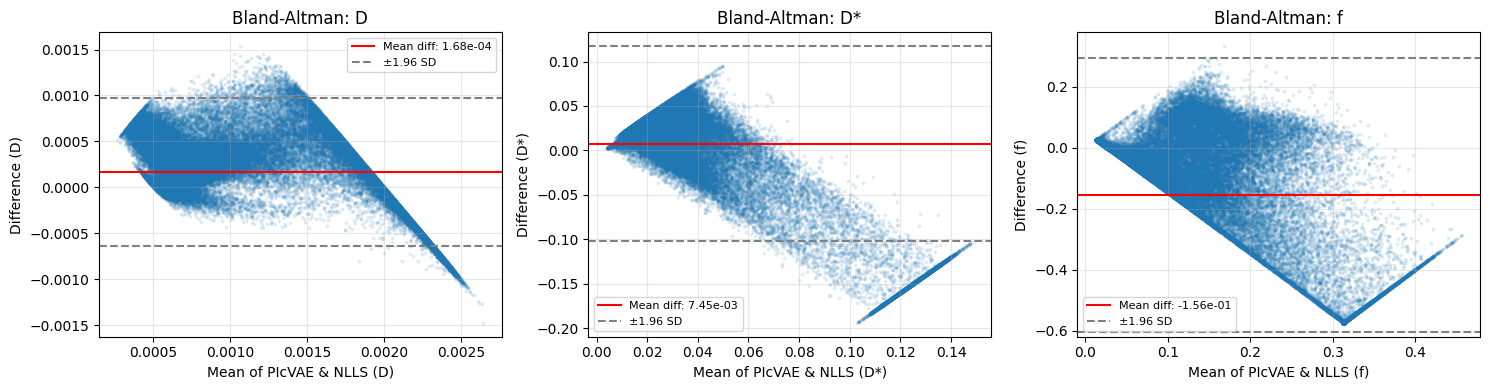


[STEP 8] Uncertainty Calibration on Synthetic Data

  --- D ---
    Level 50%: PICP=0.1726, PINAW=0.1184
    Level 80%: PICP=0.3290, PINAW=0.2250
    Level 90%: PICP=0.4197, PINAW=0.2888
    Level 95%: PICP=0.4963, PINAW=0.3442
    CRPS: 2.08e-04


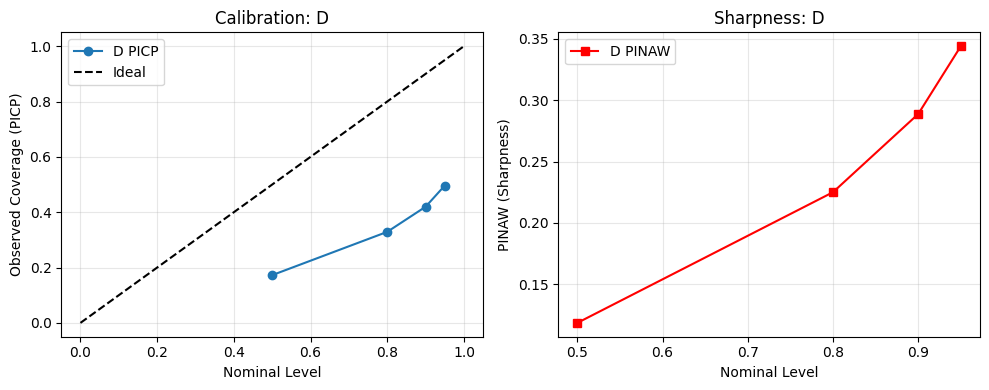

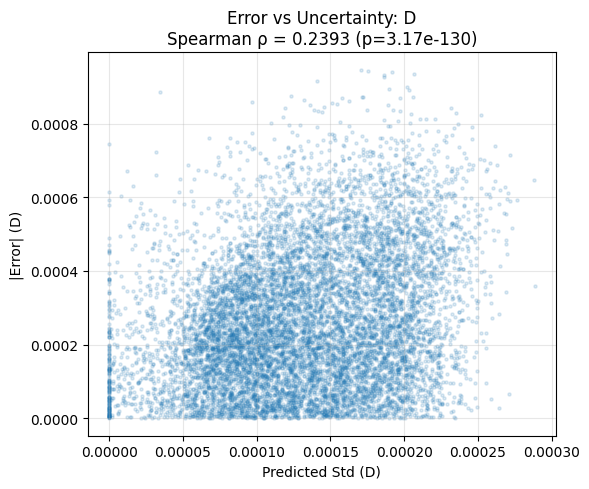


  --- D* ---
    Level 50%: PICP=0.1777, PINAW=0.1200
    Level 80%: PICP=0.3257, PINAW=0.2281
    Level 90%: PICP=0.4081, PINAW=0.2927
    Level 95%: PICP=0.4682, PINAW=0.3488
    CRPS: 1.60e-02


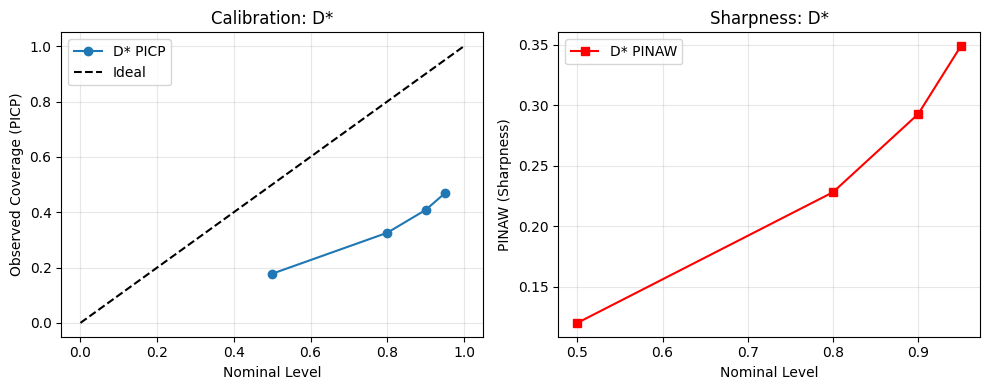

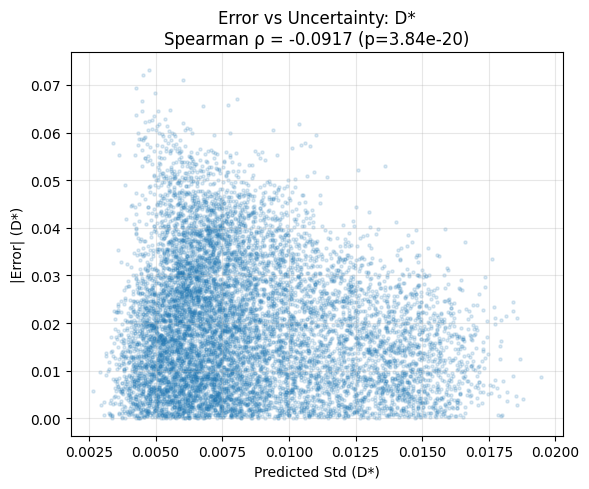


  --- f ---
    Level 50%: PICP=0.2604, PINAW=0.0822
    Level 80%: PICP=0.4604, PINAW=0.1561
    Level 90%: PICP=0.5637, PINAW=0.2004
    Level 95%: PICP=0.6387, PINAW=0.2388
    CRPS: 3.59e-02


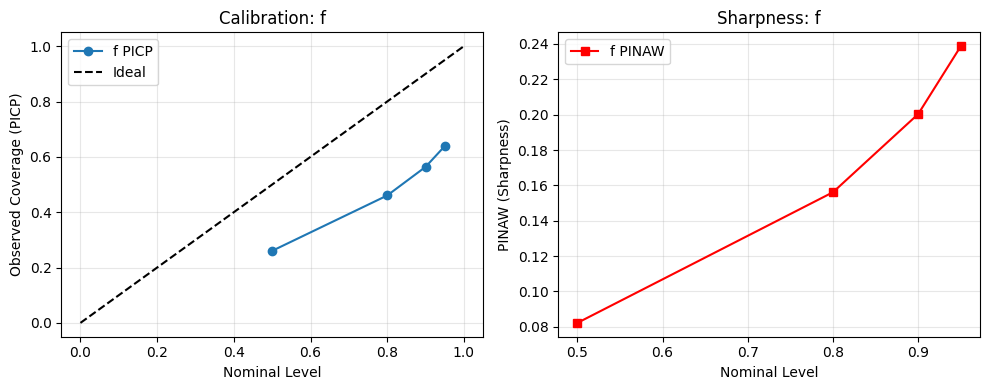

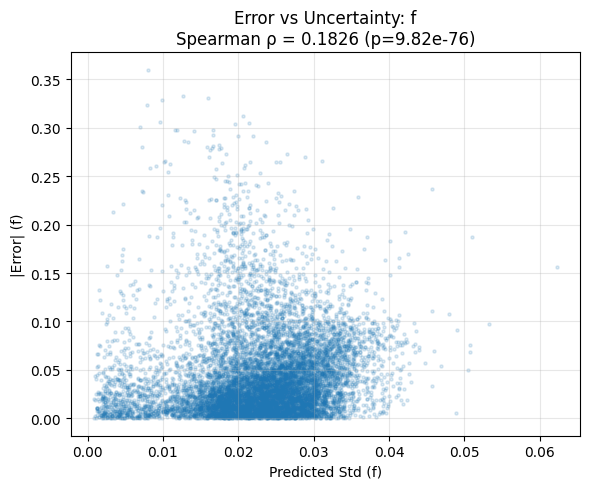


[STEP 9] Synthetic SNR Sweep (isolating accuracy from noise)

__________________________________________________________________________________________
SYNTHETIC DATA EXPERIMENTS — Accuracy vs SNR
__________________________________________________________________________________________
SNR    Method             MAE(D)         RMSE(D)        MAE(D*)        RMSE(D*)       MAE(f)         RMSE(f)       
------------------------------------------------------------------------------------------
  [nlls] Completed 10000 voxels in 56.68s
  [IVIM-NET] Epoch 50/100, Loss: 0.008667
  [IVIM-NET] Epoch 100/100, Loss: 0.008582
10     NLLS               2.88e-04       4.00e-04       4.43e-02       6.30e-02       9.74e-02       1.63e-01        (56.68s)
10     IVIM-NET           1.87e-04       2.46e-04       2.49e-02       3.26e-02       4.50e-02       6.13e-02        (0.01s)
10     PIcVAE (Ours)      2.32e-04       2.89e-04       2.15e-02       2.61e-02       4.88e-02       6.58e-02        (2.57s)


In [44]:
run_full_evaluation()